**Data sources:**
1. ACT DR6 CMB-only: `/home/jiaqu/DR6-ACT-lite/act_dr6_cmbonly/data/act_dr6_cmb_sacc.fits`

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import sacc

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

params = {'text.usetex': False, 'mathtext.fontset': 'stixsans'}
plt.rcParams.update(params)

import matplotlib as mpl
mpl.rcParams['font.size'] = 14
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

%config InlineBackend.figure_format='retina'

# ell cuts for Planck+ACT combination (following PlanckActCut.yaml)
ELL_CUTS = {
    'TT': {'planck_max': 1000, 'act_min': 600},
    'TE': {'planck_max': 600, 'act_min': 600},
    'EE': {'planck_max': 600, 'act_min': 600},
}
print("ell cuts for Planck+ACT combination:")
for spec, cuts in ELL_CUTS.items():
    print(f"  {spec}: Planck ℓ<{cuts['planck_max']}, ACT ℓ≥{cuts['act_min']}")

ell cuts for Planck+ACT combination:
  TT: Planck ℓ<1000, ACT ℓ≥600
  TE: Planck ℓ<600, ACT ℓ≥600
  EE: Planck ℓ<600, ACT ℓ≥600


## 1. Load the Data Files

In [2]:
# Load ACT DR6 SACC file
act_sacc_file = '/home/jiaqu/DR6-ACT-lite/act_dr6_cmbonly/data/act_dr6_cmb_sacc.fits'
act_s = sacc.Sacc.load_fits(act_sacc_file)
print(f"ACT SACC file loaded: {len(act_s.data)} data points")

ACT SACC file loaded: 127 data points


## 3. Extract ACT DR6 Spectra

ACT DR6 CMB-only stores bandpowers as $D_\ell$ in $\mu K^2$.

In [3]:
def extract_act_spectrum(s, data_type):
    """Extract ell, Dl, and errors for a SACC data type."""
    indices = s.indices(data_type)
    if len(indices) == 0:
        return None, None, None
    
    ells = np.array([s.data[i].get_tag('ell') for i in indices])
    dls = np.array([s.data[i].value for i in indices])
    
    if s.covariance is not None:
        errs = np.sqrt(np.diag(s.covariance.dense[np.ix_(indices, indices)]))
    else:
        errs = None
    
    sort_idx = np.argsort(ells)
    return ells[sort_idx], dls[sort_idx], errs[sort_idx] if errs is not None else None


# SACC type mappings for CMB spectra
ACT_TYPE_MAP = {'TT': 'cl_00', 'TE': 'cl_0e', 'EE': 'cl_ee'}

act_spectra = {}
for name, sacc_type in ACT_TYPE_MAP.items():
    if sacc_type in act_s.get_data_types():
        ells, dls, errs = extract_act_spectrum(act_s, sacc_type)
        if ells is not None:
            act_spectra[name] = {'ells': ells, 'dls': dls, 'errs': errs}
            print(f"ACT {name}: {len(ells)} bins, ℓ=[{ells.min():.0f}, {ells.max():.0f}]")

ACT TT: 45 bins, ℓ=[598, 6124]
ACT TE: 40 bins, ℓ=[598, 4124]
ACT EE: 42 bins, ℓ=[498, 4124]


## 4. Load Theory Power Spectra

Load fiducial theory Cℓ from orphics and convert to Dℓ = ℓ(ℓ+1)Cℓ/(2π).

In [4]:
# Load theory power spectra from orphics
from orphics import cosmology

theory = cosmology.default_theory()

# Get theory ells up to 7000
ells_theory = np.arange(2, 7001)

# Get lensed Cl in uK^2 and convert to Dl
theory_spectra = {}
for name in ['TT', 'TE', 'EE']:
    cl = theory.lCl(name, ells_theory)
    dl = ells_theory * (ells_theory + 1) / (2 * np.pi) * cl
    theory_spectra[name] = {'ells': ells_theory, 'dls': dl}
    print(f"Theory {name}: ell=[{ells_theory.min()}, {ells_theory.max()}], Dl range=[{dl.min():.1f}, {dl.max():.1f}] uK^2")

Theory TT: ell=[2, 7000], Dl range=[0.2, 5733.3] uK^2
Theory TE: ell=[2, 7000], Dl range=[-134.3, 120.2] uK^2
Theory EE: ell=[2, 7000], Dl range=[0.0, 42.4] uK^2


In [5]:
# Bin theory for ACT using SACC bandpower windows
# Following act_dr6_cmbonly.py chi_square() pattern

def bin_theory_act(sacc_obj, theory_spectra, sacc_type_map):
    """Bin theory spectra using ACT SACC bandpower windows."""
    act_theory_binned = {}
    
    for name, sacc_type in sacc_type_map.items():
        if sacc_type not in sacc_obj.get_data_types():
            continue
            
        indices = sacc_obj.indices(sacc_type)
        ells_data = np.array([sacc_obj.data[i].get_tag('ell') for i in indices])
        
        # Get bandpower windows for these indices
        windows = sacc_obj.get_bandpower_windows(indices)
        
        # windows.weight has shape (n_theory_ells, n_bins)
        # windows.values has the theory ell values
        win_matrix = windows.weight.T  # (n_bins, n_theory_ells)
        theory_ells = windows.values.astype(int)
        
        # Get theory Dl at window ells
        th = theory_spectra[name]
        # Interpolate theory to window ells if needed
        theory_dl_at_window = np.interp(theory_ells, th['ells'], th['dls'])
        
        # Bin: Dl_binned = window @ Dl_theory
        dl_binned = win_matrix @ theory_dl_at_window
        
        act_theory_binned[name] = {
            'ells': ells_data,
            'dls': dl_binned,
            'window_matrix': win_matrix,
            'window_ells': theory_ells
        }
        print(f"ACT {name} theory binned: {len(dl_binned)} bins, window shape: {win_matrix.shape}")
    
    return act_theory_binned

act_theory_binned = bin_theory_act(act_s, theory_spectra, ACT_TYPE_MAP)

ACT TT theory binned: 45 bins, window shape: (45, 6501)
ACT TE theory binned: 40 bins, window shape: (40, 4201)
ACT EE theory binned: 42 bins, window shape: (42, 4201)


In [6]:
def apply_ell_cuts(act_spec, ell_cuts):
    """Apply ell cuts to ACT dataset.
    
    Returns dictionary with cut data for each spectrum.
    """
    act_cut = {}
    
    for name in ['TT', 'TE', 'EE']:
        if name in act_spec:
            cuts = ell_cuts[name]
            mask = act_spec[name]['ells'] >= cuts['act_min']
            act_cut[name] = {
                'ells': act_spec[name]['ells'][mask],
                'dls': act_spec[name]['dls'][mask],
                'errs': act_spec[name]['errs'][mask],
            }
            print(f"ACT {name}: {mask.sum()} bins after cut (ℓ≥{cuts['act_min']})")
    
    return act_cut

act_cut = apply_ell_cuts(act_spectra, ELL_CUTS)

ACT TT: 44 bins after cut (ℓ≥600)
ACT TE: 39 bins after cut (ℓ≥600)
ACT EE: 39 bins after cut (ℓ≥600)


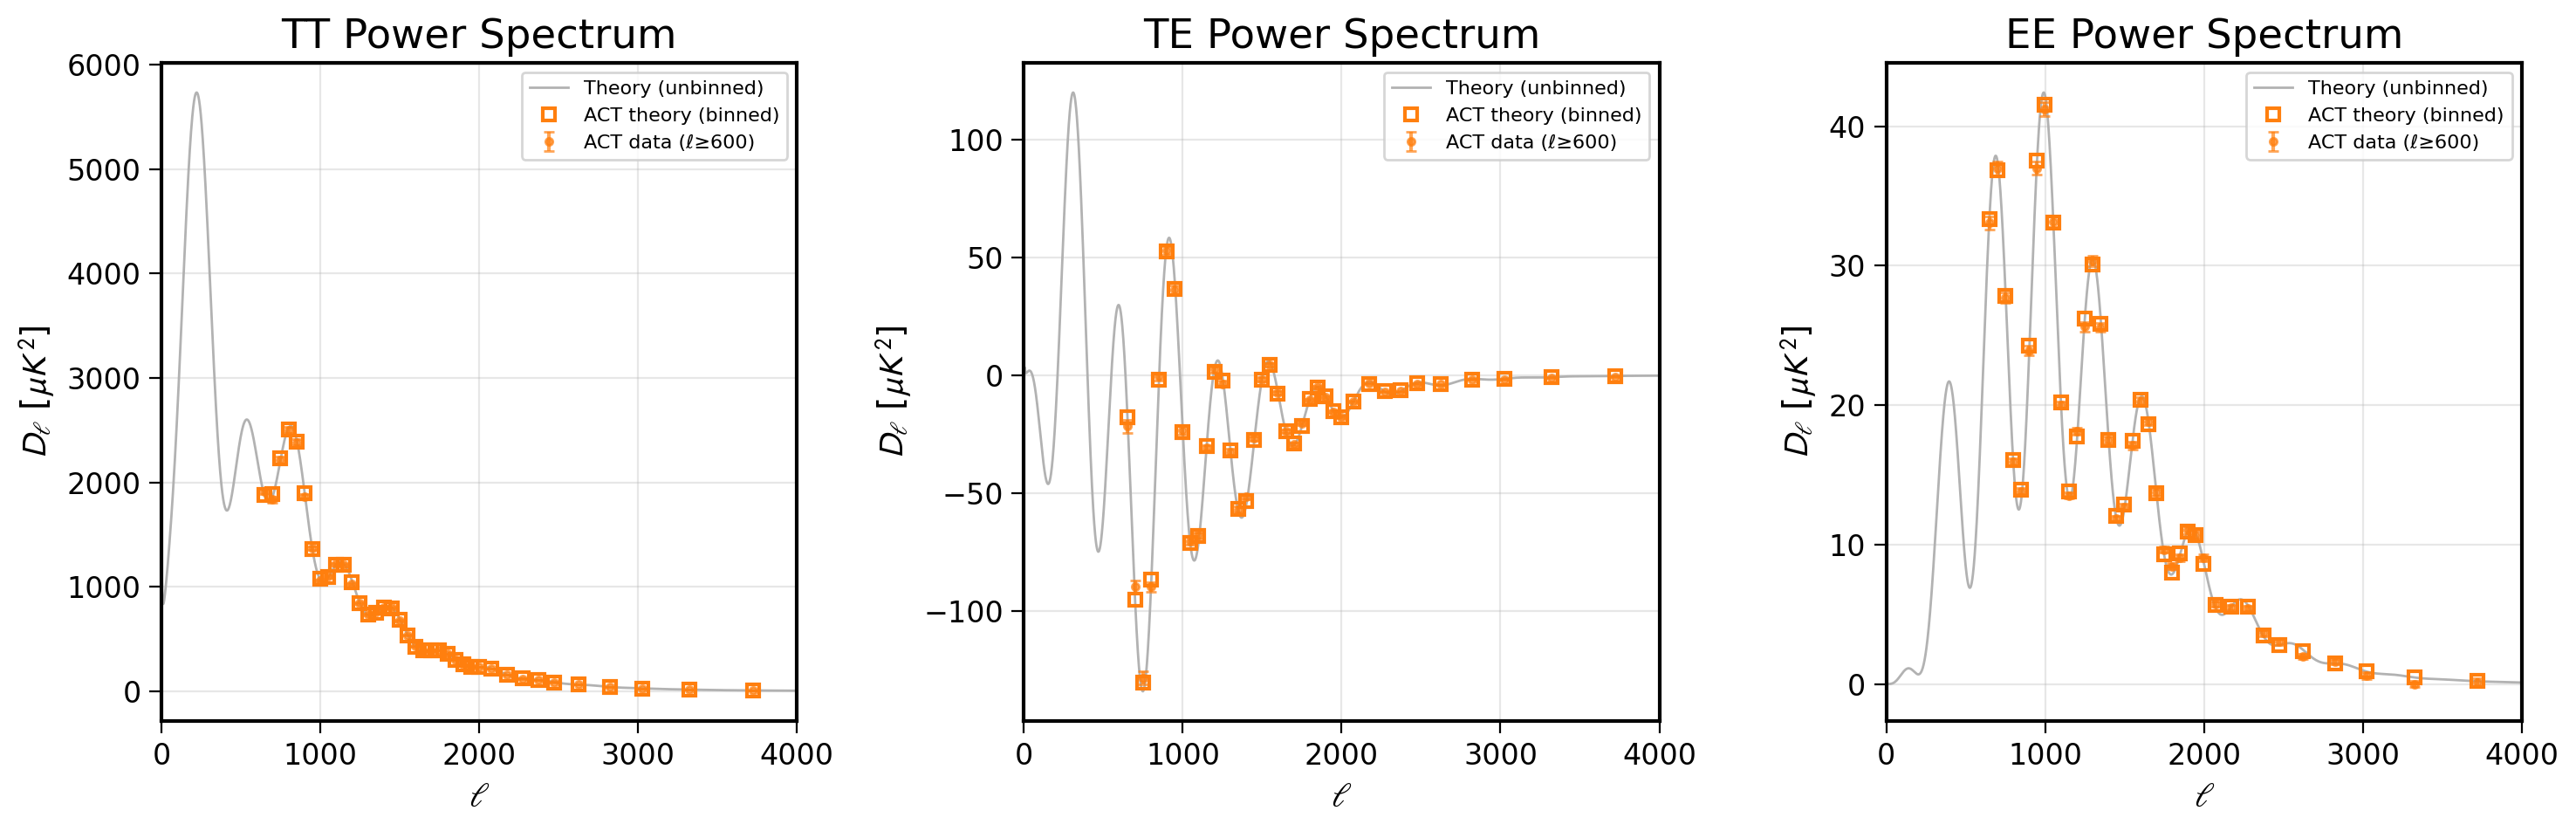

Saved: act_binned_theory.png


In [7]:
# Plot data vs binned theory (with ell cuts applied)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, name in zip(axes, ['TT', 'TE', 'EE']):
    cuts = ELL_CUTS[name]
    
    # Plot unbinned theory curve (gray, for reference)
    th = theory_spectra[name]
    ax.plot(th['ells'], th['dls'], 'k-', lw=1, alpha=0.3, label='Theory (unbinned)', zorder=0)
    

    
    # ACT: data and binned theory (ℓ >= act_min)
    if name in act_cut and name in act_theory_binned:
        a_data = act_cut[name]
        a_theory = act_theory_binned[name]
        
        # Apply cut to binned theory
        mask = a_theory['ells'] >= cuts['act_min']
        
        ax.errorbar(a_data['ells'], a_data['dls'], yerr=a_data['errs'],
                   fmt='o', capsize=2, ms=3, color='C1', alpha=0.7,
                   label=f"ACT data (ℓ≥{cuts['act_min']})", zorder=2)
        ax.plot(a_theory['ells'][mask], a_theory['dls'][mask],
               's', ms=5, color='C1', mfc='none', mew=1.5,
               label='ACT theory (binned)', zorder=3)
    
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$D_\ell$ [$\mu K^2$]')
    ax.set_title(f'{name} Power Spectrum')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 4000)

plt.tight_layout()
plt.savefig('act_binned_theory.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: act_binned_theory.png")

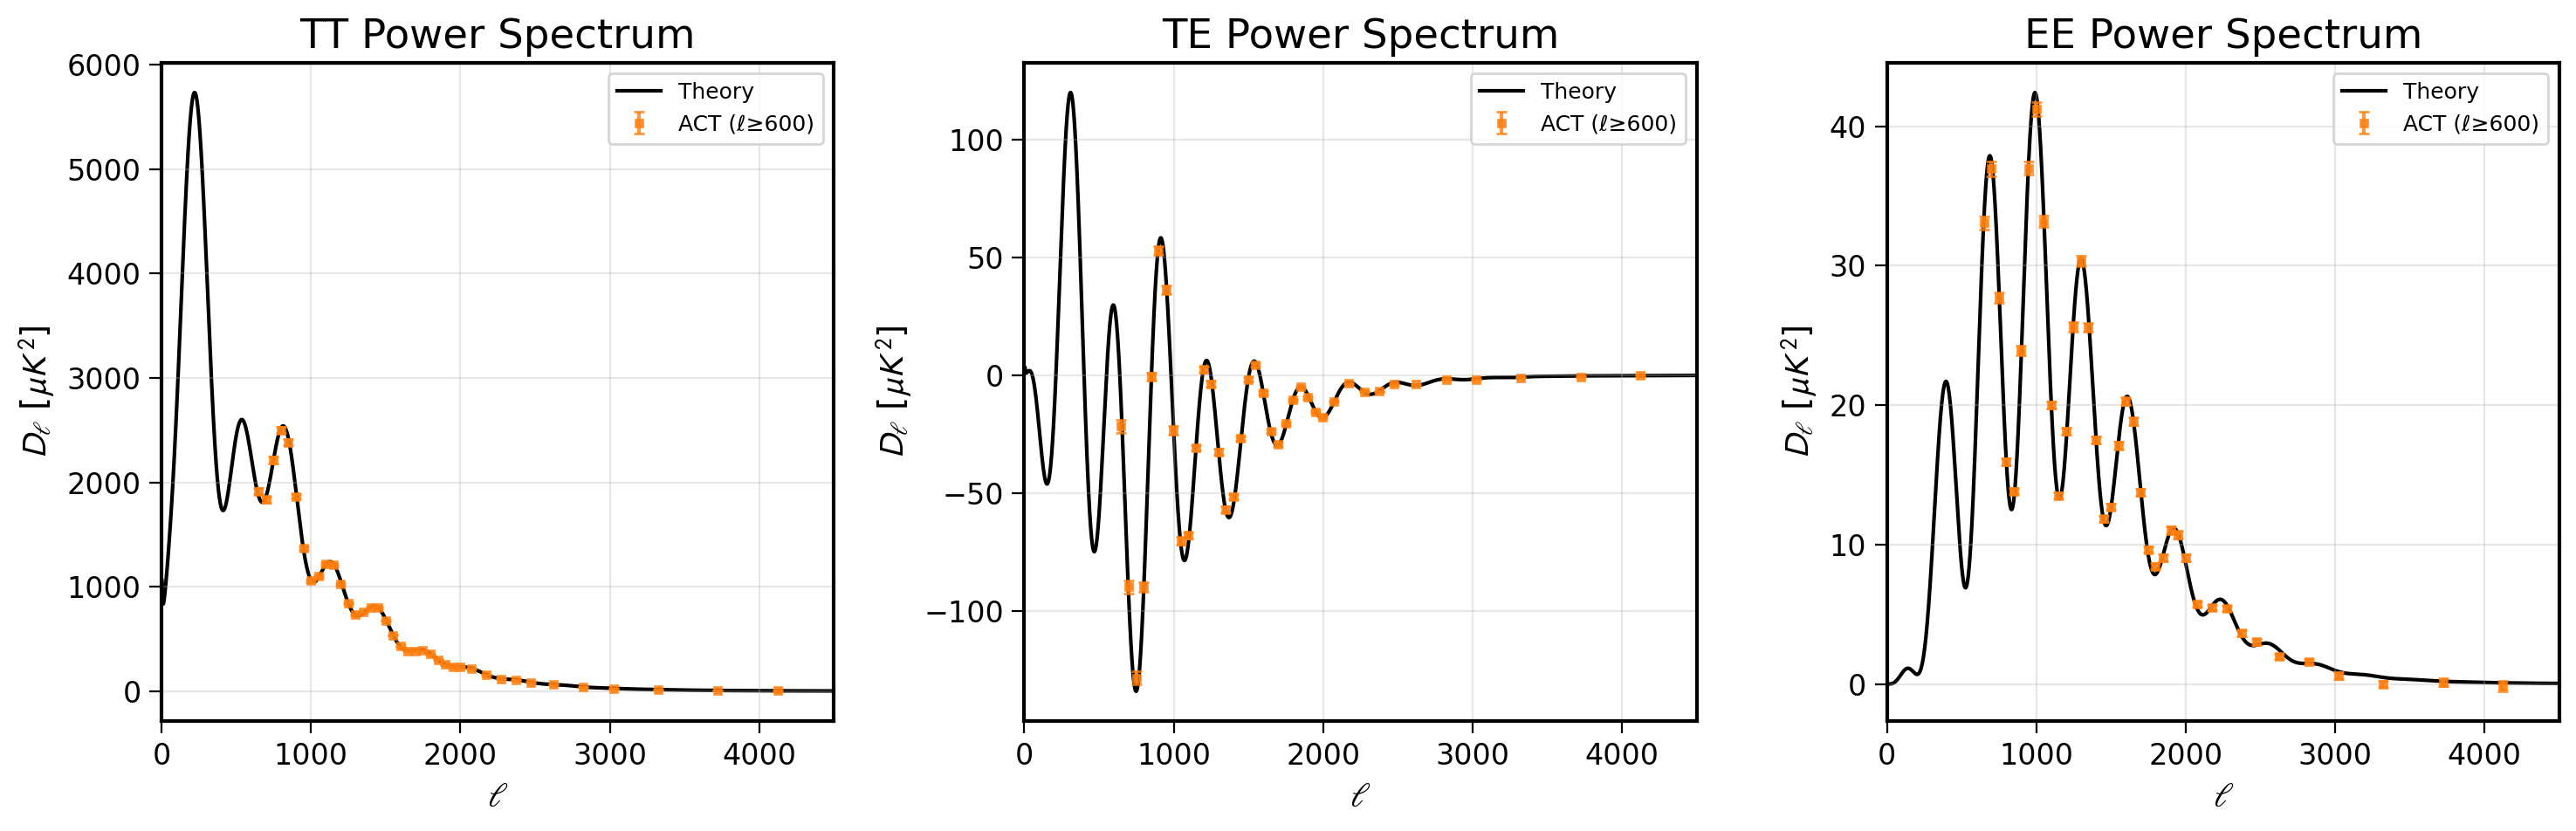

Saved: act_spectra.png


In [8]:
# Plot combined spectra with theory curves
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, name in zip(axes, ['TT', 'TE', 'EE']):
    # Plot theory curve (gray, behind data)
    if name in theory_spectra:
        th = theory_spectra[name]
        ax.plot(th['ells'], th['dls'], 'black', lw=1.5, alpha=1, label='Theory', zorder=1)
    

    
    # Plot ACT data (orange)
    if name in act_cut:
        a = act_cut[name]
        ax.errorbar(a['ells'], a['dls'], yerr=a['errs'],
                   fmt='s', capsize=2, ms=3, color='C1', alpha=0.8,
                   label=f"ACT (ℓ≥{ELL_CUTS[name]['act_min']})", zorder=2)
    
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$D_\ell$ [$\mu K^2$]')
    ax.set_title(f'{name} Power Spectrum')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Set appropriate y-limits
    if name == 'TT':
        ax.set_xlim(0, 4500)
    elif name in ['TE', 'EE']:
        ax.set_xlim(0, 4500)

plt.tight_layout()
plt.savefig('act_spectra.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: act_spectra.png")

## 7. Covariance Matrices for ACT


In [9]:
# ACT covariance from SACC (already in Dl units)
act_cov_full = act_s.covariance.covmat.copy()
print(f"ACT full covariance (Dl units): {act_cov_full.shape}")

# Apply ell cuts to ACT covariance (cut bins BELOW act_min, keep high ell)
# Uses shared ELL_CUTS dict for consistency with bandpower cuts
cl_names = ['TT', 'TE', 'EE']
act_nbins = [45, 40, 42]  # TT, TE, EE

act_cov_cut = act_cov_full.copy()
ix = 0

for xy, nbin in zip(cl_names, act_nbins):
    lmin = ELL_CUTS[xy]['act_min']  # Use shared ELL_CUTS
    
    # Get ell values for ACT bins from SACC
    sacc_type = {'TT': 'cl_00', 'TE': 'cl_0e', 'EE': 'cl_ee'}[xy]
    indices = act_s.indices(sacc_type)
    ells = np.array([act_s.data[i].get_tag('ell') for i in indices])
    
    idx = np.arange(nbin)
    mask = ells < lmin  # cut bins below lmin
    to_cut = idx[mask] + ix
    
    act_cov_cut[to_cut, :] = 0.0
    act_cov_cut[:, to_cut] = 0.0
    act_cov_cut[to_cut, to_cut] = 1e10
    
    n_kept = nbin - mask.sum()
    print(f"ACT {xy}: cut {mask.sum()} bins (ℓ<{lmin}), kept {n_kept} bins")
    
    ix += nbin

act_invcov = np.linalg.inv(act_cov_cut)
print(f"\nACT cut covariance: {act_cov_cut.shape}, condition number: {np.linalg.cond(act_cov_cut):.2e}")

ACT full covariance (Dl units): (127, 127)
ACT TT: cut 1 bins (ℓ<600), kept 44 bins
ACT TE: cut 1 bins (ℓ<600), kept 39 bins
ACT EE: cut 3 bins (ℓ<600), kept 39 bins

ACT cut covariance: (127, 127), condition number: 4.13e+11


## Eq 35 constant correction term

Where $\Delta C = C_\ell^{\mathrm{measured}} - C_\ell^{\mathrm{fiducial}}$ is the difference between measured and fiducial CMB power spectra.

$$2\left[\frac{d \ln R}{dC^j}\right]C^{\kappa\kappa,\mathrm{fiducial}} \Delta C^j  + \left[\frac{dN_1}{dC^j}\right] \Delta C^j - \left[\frac{dN_1}{dC^{\kappa\kappa}}\right]C^{\kappa\kappa,\mathrm{fiducial}}$$

## 11. Equation 34: Modified Covariance for lens_only Mode

For the `lens_only=True` mode, the lensing covariance needs to be modified to account for CMB power spectrum uncertainties:

$$\bar{\Sigma}_{ij} = \Sigma_{ij} + M_i^{X,\ell} \, \mathrm{cov}_{\mathrm{CMB}}^{X\ell;Y\ell'} \, M_j^{Y,\ell'}$$

The M matrix combines BOTH normalization and N1 CMB responses:

$$M_{i,\ell}^{X} = -2 \frac{dA_L/dC_\ell^X}{f_{A_L}}C^{\kappa\kappa,\mathrm{fiducial}}_L + \frac{dN_1}{dC^X_\ell}$$

For $X \in \{TT, EE, TE\}$ (BB excluded - no measurement).

In [10]:
# === Load likelihood correction files ===
like_corrs_dir = '/home/jiaqu/spt_act_likelihood/act_dr6_spt_lenslike/data/v1.2/like_corrs/'

# Fiducial A_L normalization: row 0 = L values, row 1 = A_L
fAL_data = np.loadtxt(f'{like_corrs_dir}/n0mv_fiducial_lmin600_lmax3000_Lmin0_Lmax4000.txt')
fAL = fAL_data[1, :]  # Shape: (4001,) for L=0 to 4000
print(f"fAL shape: {fAL.shape}, range: [{fAL[2]:.2e}, {fAL[3000]:.2e}]")

# dA_L/dC norm correction matrix: shape (4, 4001, 3001)
# Index order: [TT=0, EE=1, BB=2, TE=3]
dAL_dC = np.load(f'{like_corrs_dir}/norm_correction_matrix_Lmin0_Lmax4000.npy')
print(f"dAL_dC shape: {dAL_dC.shape}")  # (4, 4001, 3001)

# N1 derivatives: shape (3000, 3000) — output L=0-2999, input ℓ=0-2999
dN1_TT = np.loadtxt(f'{like_corrs_dir}/N1der_TT_lmin600_lmax3000_full.txt')
dN1_EE = np.loadtxt(f'{like_corrs_dir}/N1der_EE_lmin600_lmax3000_full.txt')
dN1_TE = np.loadtxt(f'{like_corrs_dir}/N1der_TE_lmin600_lmax3000_full.txt')
dN1_KK = np.loadtxt(f'{like_corrs_dir}/N1der_KK_lmin600_lmax3000_full.txt')
# Skip BB - not measured by ACT 2pt CMB
print(f"N1 derivatives shape: {dN1_TT.shape}")

# Fiducial CMB spectra (Dℓ in µK²)
fid_cls = np.loadtxt(f'{like_corrs_dir}/cosmo2017_10K_acc3_lensedCls.dat')
fid_ells = fid_cls[:, 0].astype(int)
# Convert Dℓ to Cℓ: Cℓ = Dℓ * 2π / (ℓ(ℓ+1))
ell_factor = fid_ells * (fid_ells + 1) / (2 * np.pi)
ell_factor[0] = 1  # Avoid division by zero
fid_Cl = {
    'TT': fid_cls[:, 1] / ell_factor,
    'EE': fid_cls[:, 2] / ell_factor,
    'TE': fid_cls[:, 4] / ell_factor,
}
print(f"Fiducial CMB ell range: [{fid_ells[0]}, {fid_ells[-1]}]")

# Fiducial clkk from φφ spectrum
fid_lens = np.loadtxt(f'{like_corrs_dir}/cosmo2017_10K_acc3_lenspotentialCls.dat')
L_fid = fid_lens[:, 0].astype(int)
clpp_fid = fid_lens[:, 5]
clkk_fid = clpp_fid * 2 * np.pi / 4  # Convert Cℓ^φφ to Cℓ^κκ
print(f"Fiducial clkk L range: [{L_fid[0]}, {L_fid[-1]}], shape: {clkk_fid.shape}")

fAL shape: (4001,), range: [4.66e-08, 9.50e-07]
dAL_dC shape: (4, 4001, 3001)
N1 derivatives shape: (3000, 3000)
Fiducial CMB ell range: [2, 8250]
Fiducial clkk L range: [2, 10000], shape: (9999,)


In [11]:
# === Compute ΔCℓ = ACT measured - fiducial (ℓ ≥ 600 only) ===
# Convert ACT Dℓ to Cℓ
def dl_to_cl(ells, dls):
    """Convert Dℓ to Cℓ."""
    factor = ells * (ells + 1) / (2 * np.pi)
    return dls / factor

# Interpolate ACT bandpowers to unbinned ℓ ∈ [600, 3000]
ell_range = np.arange(600, 3001)
delta_Cl = {}

for name in ['TT', 'TE', 'EE']:
    # ACT data is in Dℓ, convert to Cℓ
    act_Cl = dl_to_cl(act_cut[name]['ells'], act_cut[name]['dls'])
    # Interpolate to full ℓ range
    act_interp = np.interp(ell_range, act_cut[name]['ells'], act_Cl)
    # Fiducial at same ells
    fid_interp = np.interp(ell_range, fid_ells, fid_Cl[name])
    delta_Cl[name] = act_interp - fid_interp
    print(f"{name}: mean ΔCℓ/Cℓ_fid = {(delta_Cl[name]/fid_interp).mean():.4f}")

TT: mean ΔCℓ/Cℓ_fid = -0.0008
TE: mean ΔCℓ/Cℓ_fid = 0.1454
EE: mean ΔCℓ/Cℓ_fid = 0.0090


In [12]:
# === Eq. 35 Constant Correction ===
# Following get_corrected_clkk() pattern from dr6plus_lenslike.py (skipping BB)
#
# const = 2[d ln R/dC]·clkk_fid·ΔC + [dN1/dC]·ΔC - [dN1/dC^κκ]·clkk_fid
#
# Build full ΔCℓ array: shape (4, 3001) for ℓ=0-3000
# Index: [TT=0, EE=1, BB=2, TE=3]

delta_Cl_full = np.zeros((4, 3001))
delta_Cl_full[0, 600:3001] = delta_Cl['TT']  # TT
delta_Cl_full[1, 600:3001] = delta_Cl['EE']  # EE
# delta_Cl_full[2, :] = 0  # BB - skip (no measurement)
delta_Cl_full[3, 600:3001] = delta_Cl['TE']  # TE

print("ΔCℓ array shape:", delta_Cl_full.shape)
print(f"TT non-zero range: [{np.nonzero(delta_Cl_full[0])[0].min()}, {np.nonzero(delta_Cl_full[0])[0].max()}]")
print(f"clkk_fid shape: {clkk_fid.shape}")

# Truncate clkk_fid to match required L range (0-4000)
clkk_fid_trunc = clkk_fid[:4001]
print(f"clkk_fid_trunc shape: {clkk_fid_trunc.shape}")

# Term 1: Normalization correction
# Following dr6plus_lenslike.py lines 137-141:
# norm_corr = -2 * (dAL_dC @ ΔCℓ) / fAL, then norm_term = norm_corr * clkk_fid
norm_corr = np.zeros(4001)
for i, name in enumerate(['TT', 'EE', 'BB', 'TE']):
    if name == 'BB':
        continue  # Skip BB
    raw = dAL_dC[i] @ delta_Cl_full[i]
    # Only apply correction for L >= 2 (avoid division by zero)
    norm_corr[2:] += -2 * raw[2:] / fAL[2:]

# norm_term = norm_corr * clkk_fid (matches likelihood code line 142)
norm_term = norm_corr * clkk_fid_trunc

# Term 2: N1 CMB correction (dN1/dC @ ΔCℓ)
# Following dr6plus_lenslike.py line 135
n1_cmb_term = np.zeros(3000)
for dN1, name in [(dN1_TT, 'TT'), (dN1_EE, 'EE'), (dN1_TE, 'TE')]:
    idx = ['TT', 'EE', 'BB', 'TE'].index(name)
    n1_cmb_term += dN1 @ delta_Cl_full[idx, :3000]

# Term 3: N1 κκ correction (-dN1_KK @ clkk_fid)
# This term uses the fiducial clkk, not measured clkk
n1_kk_term = -dN1_KK @ clkk_fid_trunc[:3000]

# Total Eq. 35 constant
eq35_const = np.zeros(4001)
eq35_const[:3000] = norm_term[:3000] + n1_cmb_term + n1_kk_term

print(f"\n=== Eq. 35 Components (per clkk_fid) ===")
for L in [100, 500, 1000]:
    print(f"L={L}: norm={norm_term[L]/clkk_fid_trunc[L]*100:.4f}%, "
          f"N1_cmb={n1_cmb_term[L]/clkk_fid_trunc[L]*100:.4f}%, "
          f"N1_kk={n1_kk_term[L]/clkk_fid_trunc[L]*100:.4f}%, "
          f"total={eq35_const[L]/clkk_fid_trunc[L]*100:.4f}%")

ΔCℓ array shape: (4, 3001)
TT non-zero range: [600, 3000]
clkk_fid shape: (9999,)
clkk_fid_trunc shape: (4001,)

=== Eq. 35 Components (per clkk_fid) ===
L=100: norm=-18.8730%, N1_cmb=-0.1956%, N1_kk=-0.7142%, total=-19.7828%
L=500: norm=-3.5510%, N1_cmb=-1.3719%, N1_kk=-11.0662%, total=-15.9890%
L=1000: norm=-1.8410%, N1_cmb=-1.6891%, N1_kk=-35.4811%, total=-39.0111%


In [13]:
# === Eq. 34 Modified Covariance for lens_only Mode ===
# 
# Σ̄_ij = Σ_ij + M_i^X,ℓ · cov_CMB^Xℓ;Yℓ' · M_j^Y,ℓ'
#
# where M_i^X,ℓ = -2 (dA_L/dC^X) / f_AL * clkk_fid + dN1/dC^X
#
# For ACT-only (ℓ ≥ 600), we use ACT CMB covariance

def build_M_matrix(dAL_dC_X, dN1_X, fAL, clkk_fid_trunc, Lmax=3000):
    """Build M matrix for spectrum X.
    
    M^X_L,ℓ = -2 * dAL_dC[L, ℓ] / fAL[L] * clkk_fid[L] + dN1_X[L, ℓ]
    
    Shape: (Lmax, ℓmax) = (3000, 3000)
    """
    M = np.zeros((Lmax, 3000))
    for L in range(2, Lmax):
        if fAL[L] > 0:
            M[L, :] = -2 * dAL_dC_X[L, :3000] / fAL[L] * clkk_fid_trunc[L]
        M[L, :] += dN1_X[L, :] 
    return M

# Build M matrices for TT, EE, TE (skip BB)
print("Building M matrices...")
M_TT = build_M_matrix(dAL_dC[0], dN1_TT, fAL, clkk_fid_trunc)
M_EE = build_M_matrix(dAL_dC[1], dN1_EE, fAL, clkk_fid_trunc)
M_TE = build_M_matrix(dAL_dC[3], dN1_TE, fAL, clkk_fid_trunc)
print(f"M matrix shape: {M_TT.shape}")

# Load lensing binning matrix to transform M from L to lensing bins
ddir = '/home/jiaqu/spt_act_likelihood/act_dr6_spt_lenslike/data/v1.2/'
lens_binmat = np.loadtxt(f'{ddir}/binning_matrix_act.txt')
print(f"Lensing binning matrix shape: {lens_binmat.shape}")

# Bin M matrices along L dimension: M_binned[bin_i, ℓ] = lens_binmat[bin_i, L] @ M[L, ℓ]
# lens_binmat has shape (nbins, Lmax_lens), M has shape (Lmax, ℓmax)
nbins_lens = lens_binmat.shape[0]
Lmax_lens = lens_binmat.shape[1]

# === PRODUCTION MODE: Use FULL bins (no cuts) ===
# NOTE: The 2:-6 bin cuts are applied later in dr6plus_lenslike.py during load_data(),
# NOT in this covariance computation. Here we save the FULL 18-bin covariance.

M_TT_binned = lens_binmat @ M_TT[:Lmax_lens, :]
M_EE_binned = lens_binmat @ M_EE[:Lmax_lens, :]
M_TE_binned = lens_binmat @ M_TE[:Lmax_lens, :]
print(f"M binned shape (full bins, no cuts): {M_TT_binned.shape}")

# === UNIT CONVERSION ===
# ACT covariance is in Dℓ² units, but M is built for Cℓ
# Convert M to work with Dℓ: M_Dl[i, ℓ] = M_Cl[i, ℓ] * 2π / (ℓ(ℓ+1))
ells_for_M = np.arange(M_TT_binned.shape[1])
ell_factor = ells_for_M * (ells_for_M + 1) / (2 * np.pi)
ell_factor[0] = 1  # Avoid division by zero at ℓ=0

# Broadcast division over ℓ dimension
M_TT_binned = M_TT_binned / ell_factor[np.newaxis, :]
M_EE_binned = M_EE_binned / ell_factor[np.newaxis, :]
M_TE_binned = M_TE_binned / ell_factor[np.newaxis, :]
print(f"M matrices converted to Dℓ units")

n_lens_bins = M_TT_binned.shape[0]
print(f"Using FULL {n_lens_bins} lensing bins (no bin cuts applied)")

Building M matrices...
M matrix shape: (3000, 3000)
Lensing binning matrix shape: (18, 3000)
M binned shape (full bins, no cuts): (18, 3000)
M matrices converted to Dℓ units
Using FULL 18 lensing bins (no bin cuts applied)


In [14]:
def build_M_matrix_test(dAL_dC_X, dN1_X, fAL, clkk_fid_trunc, Lmax=3000):
    """Build M matrix for spectrum X.
    
    M^X_L,ℓ = -2 * dAL_dC[L, ℓ] / fAL[L] * clkk_fid[L] + dN1_X[L, ℓ]
    
    Shape: (Lmax, ℓmax) = (3000, 3000)
    """
    M = np.zeros((Lmax, 3000))
    for L in range(2, Lmax):
        if fAL[L] > 0:
            M[L, :] = -2 * dAL_dC_X[L, :3000] / fAL[L] * clkk_fid_trunc[L]
        M[L, :] += dN1_X[L, :]
    return M

# Build M matrices for TT, EE, TE (skip BB)
print("Building M matrices...")
M_TT_test = build_M_matrix_test(dAL_dC[0], dN1_TT, fAL, clkk_fid_trunc)

Building M matrices...


In [15]:
# === Transform M matrices to ACT CMB bin space ===
# 
# ACT CMB covariance is in binned Dℓ² units
# M matrices are in [1/Cℓ] units
# Need to apply bandpower windows to bin M along ℓ dimension

# Get ACT bandpower windows for each spectrum
def get_act_windows(sacc_obj, sacc_type, ell_min=600):
    """Get bandpower windows for ACT CMB spectrum (ℓ >= ell_min only)."""
    indices = sacc_obj.indices(sacc_type)
    ells = np.array([sacc_obj.data[i].get_tag('ell') for i in indices])
    
    # Filter to ℓ >= ell_min
    mask = ells >= ell_min
    indices_cut = [idx for idx, m in zip(indices, mask) if m]
    
    windows = sacc_obj.get_bandpower_windows(indices_cut)
    win_matrix = windows.weight.T  # (n_bins, n_theory_ells)
    theory_ells = windows.values.astype(int)
    
    return win_matrix, theory_ells, ells[mask]

# Get windows for TT, TE, EE
win_TT, ells_win_TT, act_ells_TT = get_act_windows(act_s, 'cl_00', ell_min=600)
win_TE, ells_win_TE, act_ells_TE = get_act_windows(act_s, 'cl_0e', ell_min=600)
win_EE, ells_win_EE, act_ells_EE = get_act_windows(act_s, 'cl_ee', ell_min=600)

print(f"ACT TT: {win_TT.shape[0]} bins, window ell range: [{ells_win_TT.min()}, {ells_win_TT.max()}]")
print(f"ACT TE: {win_TE.shape[0]} bins, window ell range: [{ells_win_TE.min()}, {ells_win_TE.max()}]")
print(f"ACT EE: {win_EE.shape[0]} bins, window ell range: [{ells_win_EE.min()}, {ells_win_EE.max()}]")

# Bin M matrices along ℓ dimension using ACT windows
# FIXED: Use simple sum over bin support, not window-weighted (per DR6 paper)
def doubly_bin_M(M_binned, window, ells_win):
    """Bin M matrix along ℓ dimension using bandpower windows.
    
    For each CMB bin b, identify ℓ values where window[b, ℓ] > 1e-10
    and sum M_binned[i, ℓ] over those ℓ values (NO weighting).
    This assumes smooth CMB variation within each bin (per DR6 paper).
    
    Args:
        M_binned: (n_lens_bins, 3000) - lensing-binned M matrix (Dℓ units)
        window: (n_cmb_bins, n_ells) - CMB bandpower window
        ells_win: (n_ells,) - ell values for window
        
    Returns:
        M_doubly_binned: (n_lens_bins, n_cmb_bins)
    """
    n_lens_bins = M_binned.shape[0]
    n_cmb_bins = window.shape[0]
    M_doubly = np.zeros((n_lens_bins, n_cmb_bins))
    
    # Extract M at window ells
    ells_valid = ells_win[ells_win < M_binned.shape[1]]
    n_valid = len(ells_valid)
    
    for b in range(n_cmb_bins):
        # Identify ℓ values in this bin's support (window > threshold)
        bin_support = window[b, :n_valid] > 1e-10
        for i in range(n_lens_bins):
            # Simple sum over bin support (NO weighting)
            M_doubly[i, b] = np.sum(M_binned[i, ells_valid[bin_support]])
    
    return M_doubly

# Doubly bin M matrices
M_TT_doubly = doubly_bin_M(M_TT_binned, win_TT, ells_win_TT)
M_EE_doubly = doubly_bin_M(M_EE_binned, win_EE, ells_win_EE)
M_TE_doubly = doubly_bin_M(M_TE_binned, win_TE, ells_win_TE)

print(f"\nDoubly-binned M shapes:")
print(f"  M_TT: {M_TT_doubly.shape} (lens_bins x cmb_TT_bins)")
print(f"  M_EE: {M_EE_doubly.shape} (lens_bins x cmb_EE_bins)")
print(f"  M_TE: {M_TE_doubly.shape} (lens_bins x cmb_TE_bins)")

ACT TT: 44 bins, window ell range: [2, 6502]
ACT TE: 39 bins, window ell range: [2, 4202]
ACT EE: 39 bins, window ell range: [2, 4202]

Doubly-binned M shapes:
  M_TT: (18, 44) (lens_bins x cmb_TT_bins)
  M_EE: (18, 39) (lens_bins x cmb_EE_bins)
  M_TE: (18, 39) (lens_bins x cmb_TE_bins)


In [16]:
# === Extract ACT CMB covariance blocks (ℓ ≥ 600 only) ===
#
# The ACT SACC covariance is organized as [TT, TE, EE] with bins:
#   TT: 45 bins total, 44 with ℓ >= 600
#   TE: 40 bins total, 39 with ℓ >= 600
#   EE: 42 bins total, 39 with ℓ >= 600

# Get indices for each spectrum after ell cut
def get_cut_indices(sacc_obj, sacc_type, ell_min):
    """Get SACC indices for bins with ℓ >= ell_min."""
    indices = sacc_obj.indices(sacc_type)
    ells = np.array([sacc_obj.data[i].get_tag('ell') for i in indices])
    mask = ells >= ell_min
    return np.array(indices)[mask]

idx_TT = get_cut_indices(act_s, 'cl_00', 600)
idx_TE = get_cut_indices(act_s, 'cl_0e', 600)
idx_EE = get_cut_indices(act_s, 'cl_ee', 600)

print(f"ACT CMB bins after ℓ≥600 cut:")
print(f"  TT: {len(idx_TT)} bins")
print(f"  TE: {len(idx_TE)} bins")
print(f"  EE: {len(idx_EE)} bins")

# Extract covariance blocks
full_cov = act_s.covariance.covmat

# Build block covariance
# Note: SACC stores full covariance, we extract blocks for cut indices
cov_TT_TT = full_cov[np.ix_(idx_TT, idx_TT)]
cov_TT_TE = full_cov[np.ix_(idx_TT, idx_TE)]
cov_TT_EE = full_cov[np.ix_(idx_TT, idx_EE)]
cov_TE_TE = full_cov[np.ix_(idx_TE, idx_TE)]
cov_TE_EE = full_cov[np.ix_(idx_TE, idx_EE)]
cov_EE_EE = full_cov[np.ix_(idx_EE, idx_EE)]

print(f"\nACT CMB covariance block shapes:")
print(f"  TT-TT: {cov_TT_TT.shape}")
print(f"  TT-TE: {cov_TT_TE.shape}")
print(f"  TT-EE: {cov_TT_EE.shape}")
print(f"  TE-TE: {cov_TE_TE.shape}")
print(f"  TE-EE: {cov_TE_EE.shape}")
print(f"  EE-EE: {cov_EE_EE.shape}")

ACT CMB bins after ℓ≥600 cut:
  TT: 44 bins
  TE: 39 bins
  EE: 39 bins

ACT CMB covariance block shapes:
  TT-TT: (44, 44)
  TT-TE: (44, 39)
  TT-EE: (44, 39)
  TE-TE: (39, 39)
  TE-EE: (39, 39)
  EE-EE: (39, 39)


In [23]:
# === Compute Eq. 34 Modified Covariance ===
#
# Σ̄_ij = Σ_ij + M_i^X · cov_CMB^XY · M_j^Y
#
# 9 terms: TT-TT, TT-TE, TT-EE, TE-TT, TE-TE, TE-EE, EE-TT, EE-TE, EE-EE
# Symmetric, so: TT-TT + 2*(TT-TE) + 2*(TT-EE) + TE-TE + 2*(TE-EE) + EE-EE

# Load original lensing covariance (FULL matrix, no bin cuts)
lens_cov_orig = np.loadtxt(f'{ddir}/covmat_act.txt')
print(f"Original lensing covariance shape (full): {lens_cov_orig.shape}")

# Compute covariance addition term: M @ cov_CMB @ M.T
# Each term is M_X @ cov_XY @ M_Y.T
cov_add = np.zeros((n_lens_bins, n_lens_bins))

# TT-TT
cov_add += M_TT_doubly @ cov_TT_TT @ M_TT_doubly.T

# TT-TE (symmetric: also TE-TT)
cov_add += M_TT_doubly @ cov_TT_TE @ M_TE_doubly.T
cov_add += M_TE_doubly @ cov_TT_TE.T @ M_TT_doubly.T

# TT-EE (symmetric: also EE-TT)
cov_add += M_TT_doubly @ cov_TT_EE @ M_EE_doubly.T
cov_add += M_EE_doubly @ cov_TT_EE.T @ M_TT_doubly.T

# TE-TE
cov_add += M_TE_doubly @ cov_TE_TE @ M_TE_doubly.T

# TE-EE (symmetric: also EE-TE)
cov_add += M_TE_doubly @ cov_TE_EE @ M_EE_doubly.T
cov_add += M_EE_doubly @ cov_TE_EE.T @ M_TE_doubly.T

# EE-EE
cov_add += M_EE_doubly @ cov_EE_EE @ M_EE_doubly.T

print(f"Covariance addition shape: {cov_add.shape}")

# Modified covariance (FULL 18x18 matrix)
lens_cov_modified = lens_cov_orig + cov_add

# Check positive definiteness
eigvals = np.linalg.eigvalsh(lens_cov_modified)
print(f"Modified covariance eigenvalues: min={eigvals.min():.2e}, max={eigvals.max():.2e}")
print(f"Positive definite: {eigvals.min() > 0}")

# Compute diagonal increase for ALL bins
diag_orig = np.sqrt(np.diag(lens_cov_orig))
diag_modified = np.sqrt(np.diag(lens_cov_modified))
diag_increase = (diag_modified - diag_orig) / diag_orig * 100

print(f"\nDiagonal increase (%) for FULL {n_lens_bins} bins:")
print(f"  Min: {diag_increase.min():.2f}%")
print(f"  Max: {diag_increase.max():.2f}%")
print(f"  Mean: {diag_increase.mean():.2f}%")

Original lensing covariance shape (full): (18, 18)
Covariance addition shape: (18, 18)
Modified covariance eigenvalues: min=2.32e-18, max=1.95e-15
Positive definite: True

Diagonal increase (%) for FULL 18 bins:
  Min: 0.06%
  Max: 1.17%
  Mean: 0.31%


In [18]:
# === Save Outputs (diagnostic files in notebooks/) ===

# Save Eq. 35 constant correction
np.save('eq35_constant_correction.npy', {
    'L': np.arange(len(eq35_const)),
    'eq35_const': eq35_const,
    'norm_term': norm_term,
    'n1_cmb_term': n1_cmb_term,
    'n1_kk_term': n1_kk_term,
    'clkk_fid': clkk_fid_trunc,
})
print("Saved: eq35_constant_correction.npy")

# Save as text file too
np.savetxt('eq35_constant_correction.txt',
           np.column_stack([np.arange(3000), norm_term[:3000], n1_cmb_term, n1_kk_term, eq35_const[:3000]]),
           header='L norm_term n1_cmb_term n1_kk_term total',
           fmt='%d %.10e %.10e %.10e %.10e')
print("Saved: eq35_constant_correction.txt")

# Save Eq. 34 modified covariance (diagnostic version)
np.save('eq34_modified_covariance.npy', {
    'cov_modified': lens_cov_modified,
    'cov_original': lens_cov_orig,
    'cov_add': cov_add,
    'diag_increase_pct': diag_increase,
    'n_bins': n_lens_bins,
})
print("Saved: eq34_modified_covariance.npy")

Saved: eq35_constant_correction.npy
Saved: eq35_constant_correction.txt
Saved: eq34_modified_covariance.npy


In [19]:
# Compute L bin centers for all 18 bins
L_bin_centers = lens_binmat @ np.arange(3000)
print(f"L bin centers (all {len(L_bin_centers)} bins):")
print(L_bin_centers)

L bin centers (all 18 bins):
[  14.5   30.5   53.    83.5  123.   172.   231.5  301.5  382.5  476.
  582.   700.5  832.5 1001.  1200.  1400.  1600.  1874. ]


In [20]:
Llens

NameError: name 'Llens' is not defined

In [ ]:
# === Diagnostic Plots ===

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Eq. 35 correction components (L = 40 to 1000)
ax = axes[0, 0]
L_plot = np.arange(40, 1001)
ax.plot(L_plot, norm_term[40:1001] / clkk_fid_trunc[40:1001] * 100, label='Normalization', lw=2)
ax.plot(L_plot, n1_cmb_term[40:1001] / clkk_fid_trunc[40:1001] * 100, label='N1 CMB', lw=2)
ax.plot(L_plot, n1_kk_term[40:1001] / clkk_fid_trunc[40:1001] * 100, label='N1 κκ', lw=2)
ax.plot(L_plot, (eq35_const[40:1001]-n1_kk_term[40:1001]) / clkk_fid_trunc[40:1001] * 100, 'k--', label='Total', lw=2)
ax.set_xlabel('L')
ax.set_ylabel('Eq. 35 correction (% of clkk_fid)')
ax.set_xlim(40, 1000)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title('Eq. 35 Constant Correction (ACT-only CMB)')

# Plot 2: Eq. 35 total correction (L = 40 to 2000)
ax = axes[0, 1]
L_plot2 = np.arange(40, 2001)
ax.plot(L_plot2, eq35_const[40:2001] / clkk_fid_trunc[40:2001] * 100, 'C0', lw=2)
ax.set_xlabel('L')
ax.set_ylabel('Total Eq. 35 correction (% of clkk_fid)')
ax.set_xlim(40, 2000)
ax.axhline(0, color='k', ls='--', alpha=0.5)
ax.grid(True, alpha=0.3)
ax.set_title('Eq. 35 Total Correction')

# Plot 3: Modified covariance diagonal increase (all 18 bins)
ax = axes[1, 0]
lens_bins = np.arange(n_lens_bins)
ax.bar(lens_bins, diag_increase, color='C0', alpha=0.7)
ax.set_xlabel('Lensing Bin Index')
ax.set_ylabel('Diagonal increase (%)')
ax.set_title(f'Eq. 34: Diagonal Increase of covmat (all {n_lens_bins} bins)')
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Covariance matrices comparison
ax = axes[1, 1]
# Plot correlation difference
corr_orig = lens_cov_orig / np.outer(np.sqrt(np.diag(lens_cov_orig)), np.sqrt(np.diag(lens_cov_orig)))
corr_mod = lens_cov_modified / np.outer(np.sqrt(np.diag(lens_cov_modified)), np.sqrt(np.diag(lens_cov_modified)))
im = ax.imshow(corr_mod - corr_orig, cmap='RdBu_r', vmin=-0.1, vmax=0.1)
ax.set_xlabel('Lensing bin j')
ax.set_ylabel('Lensing bin i')
ax.set_title('Eq. 34: Correlation Matrix Difference')
plt.colorbar(im, ax=ax, label='Δρ')

plt.tight_layout()
plt.savefig('eq34_modified_covariance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eq34_modified_covariance.png")

In [280]:
import numpy as np
import matplotlib.pyplot as plt
import sacc

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

params = {'text.usetex': False, 'mathtext.fontset': 'stixsans'}
plt.rcParams.update(params)

import matplotlib as mpl
mpl.rcParams['font.size'] = 18
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14

%config InlineBackend.figure_format='retina'

Loaded cmbmarg covariance shape: (18, 18)


/tmp/ipykernel_2056019/3357805758.py:6: RuntimeWarning: invalid value encountered in sqrt
  diag_increase_cmbmarg = (np.diag(np.sqrt(cov_cmbmarg)) - np.diag(np.sqrt(lens_cov_orig))) / np.diag(np.sqrt(lens_cov_orig)) * 100


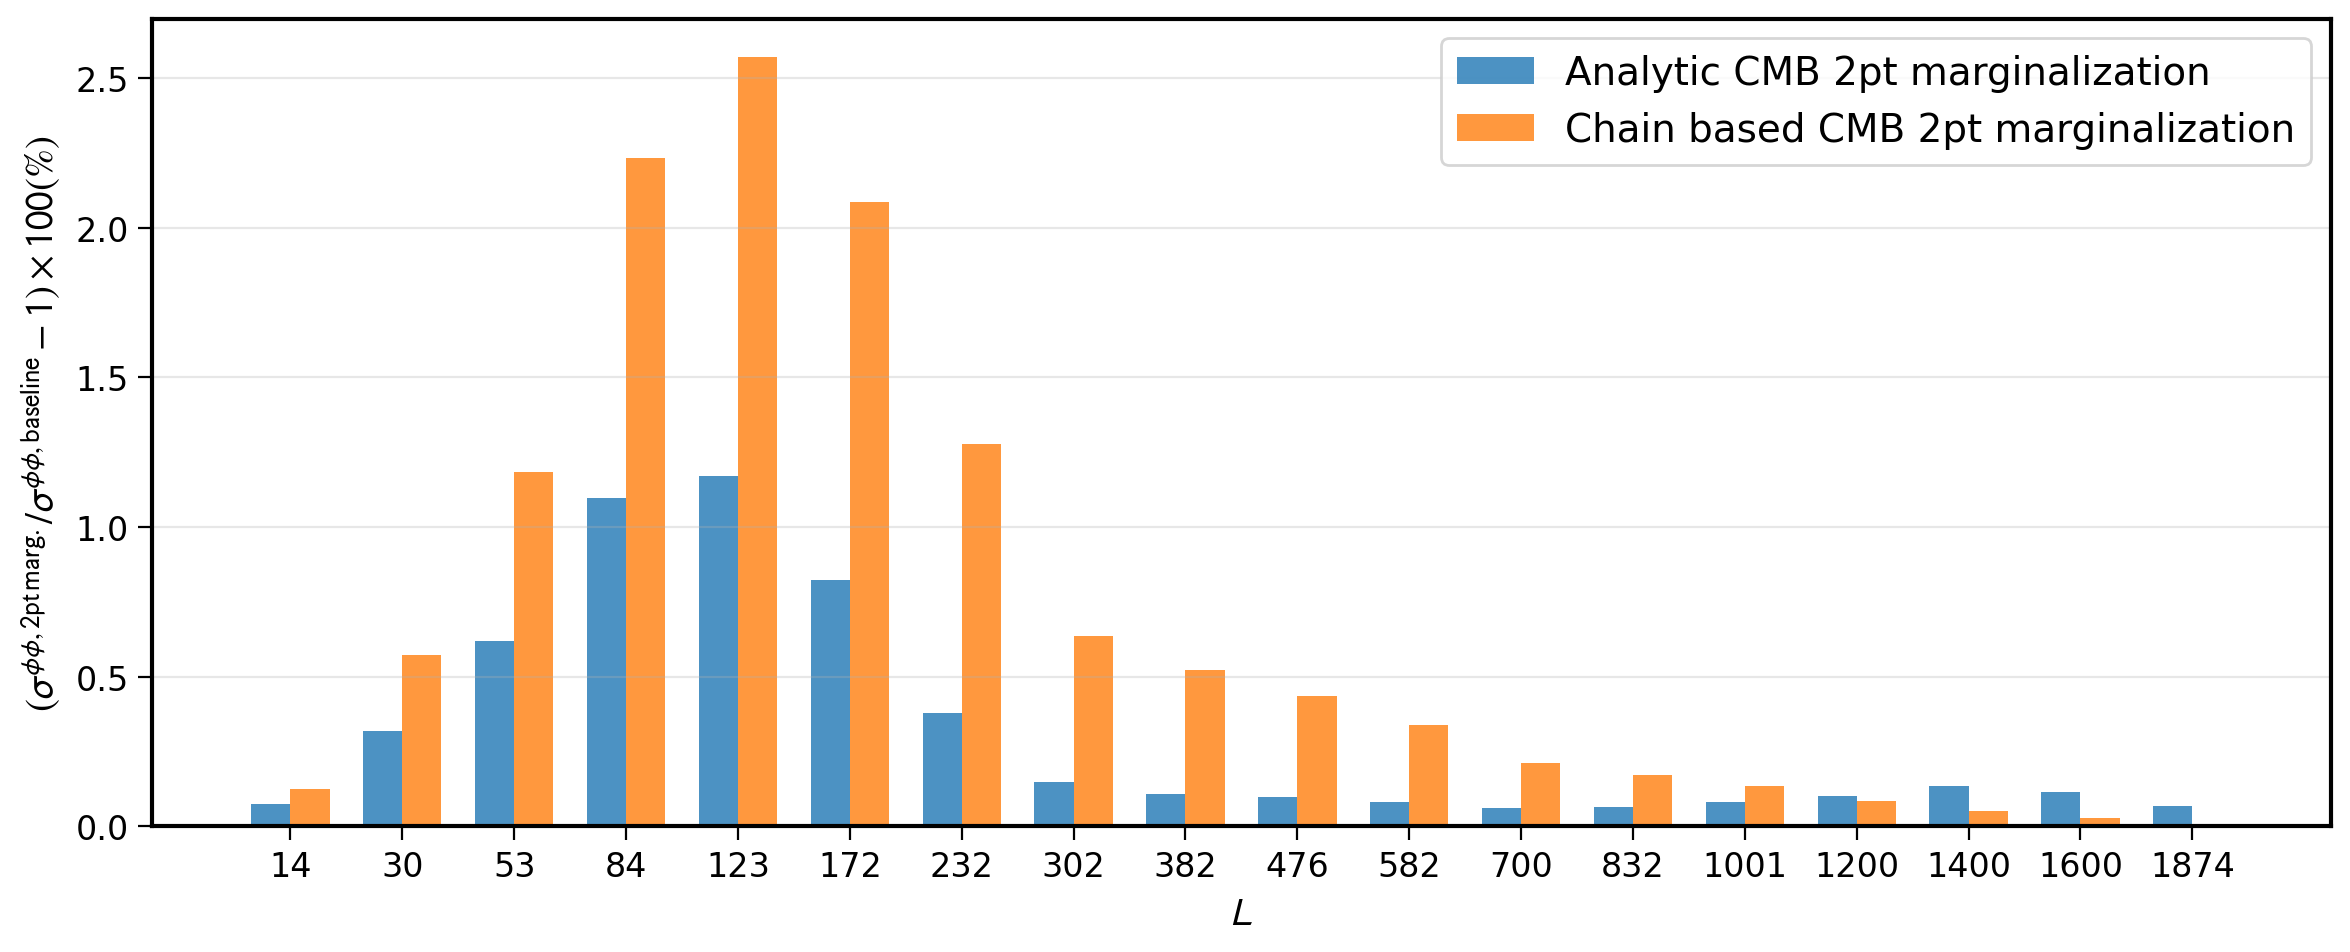

In [24]:
# Load pre-computed CMB-marginalized covariance for comparison (FULL 18x18 matrix)
cov_cmbmarg = np.loadtxt('/home/jiaqu/dr6plus_lenslike/dr6plus_lenslike/data/v1.0/covmat_act_cmbmarg.txt')
print(f"Loaded cmbmarg covariance shape: {cov_cmbmarg.shape}")

# Compute diagonal increase for CMB-marg covariance
diag_increase_cmbmarg = (np.diag(np.sqrt(cov_cmbmarg)) - np.diag(np.sqrt(lens_cov_orig))) / np.diag(np.sqrt(lens_cov_orig)) * 100

# Make standalone plot
fig, ax = plt.subplots(figsize=(12, 5))

lens_bins = np.arange(n_lens_bins)
width = 0.35

ax.bar(lens_bins - width/2, diag_increase, width, color='C0', alpha=0.8, label='Analytic CMB 2pt marginalization')
ax.bar(lens_bins + width/2, diag_increase_cmbmarg, width, color='C1', alpha=0.8, label='Chain based CMB 2pt marginalization')

ax.set_xticks(lens_bins)
ax.set_xticklabels([f'{L:.0f}' for L in L_bin_centers])
ax.set_xlabel('$L$')
#ax.set_ylabel('Diagonal increase (%)')
ax.set_ylabel(r'$\left( \sigma^{\phi\phi, \mathrm{2pt\, marg.}} / \sigma^{\phi\phi, \mathrm{baseline}} - 1 \right) \times 100(\%)$')
#ax.set_title(f'Diagonal Increase of Lensing Covariance (all {n_lens_bins} bins)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('cov_diagonal_increase.pdf', dpi=150, bbox_inches='tight')
plt.show()

Loaded cmbmarg covariance shape: (18, 18)


/tmp/ipykernel_2056019/3198138855.py:7: RuntimeWarning: invalid value encountered in sqrt
  diag_increase_cmbmarg = (np.diag(np.sqrt(cov_cmbmarg)) - np.diag(np.sqrt(lens_cov_orig))) / np.diag(np.sqrt(lens_cov_orig)) * 100
/tmp/ipykernel_2056019/3198138855.py:8: RuntimeWarning: invalid value encountered in sqrt
  diag_increase_new = (np.diag(np.sqrt(cov_rerun)) - np.diag(np.sqrt(lens_cov_orig))) / np.diag(np.sqrt(lens_cov_orig)) * 100


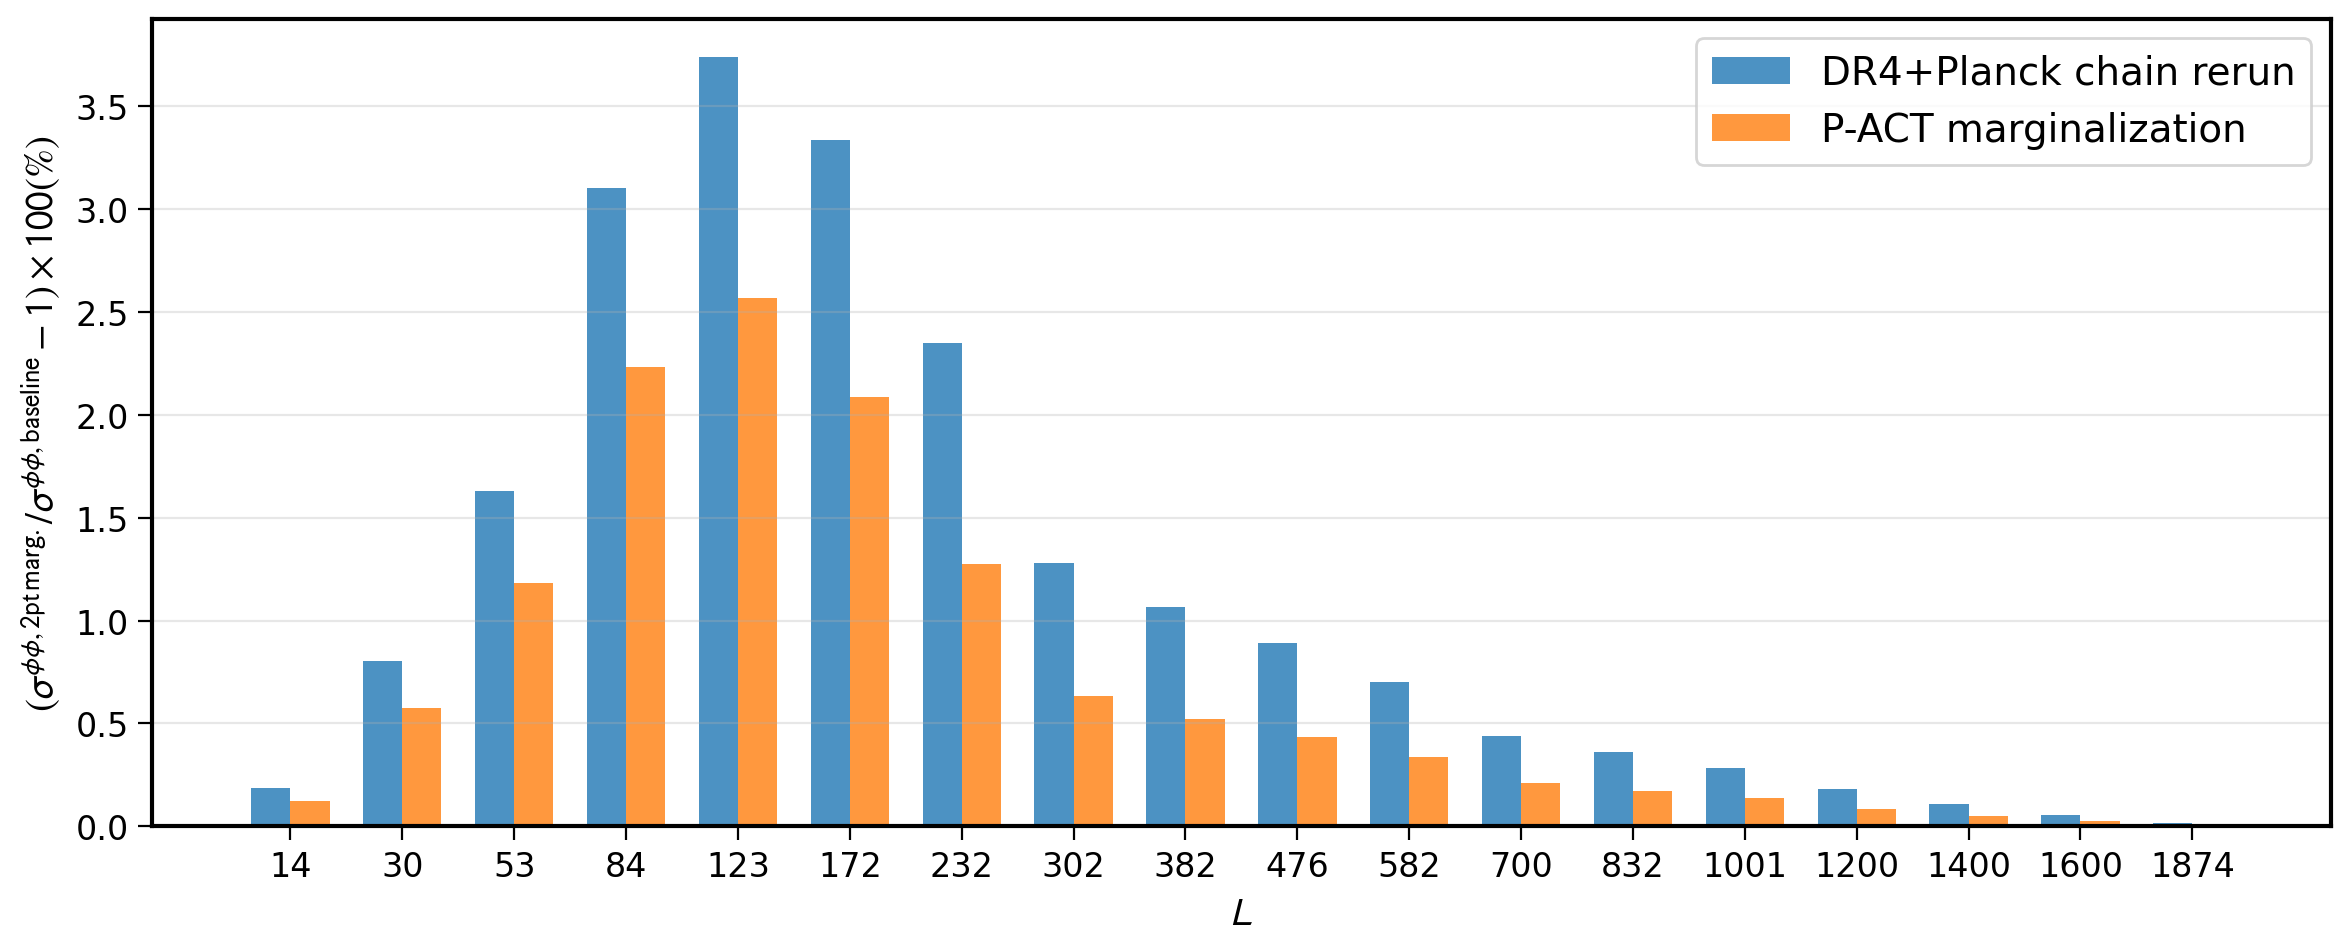

In [31]:
# Load pre-computed CMB-marginalized covariance for comparison (FULL 18x18 matrix)
cov_cmbmarg = np.loadtxt('/home/jiaqu/dr6plus_lenslike/dr6plus_lenslike/data/v1.0/covmat_act_cmbmarg.txt')
print(f"Loaded cmbmarg covariance shape: {cov_cmbmarg.shape}")
cov_rerun = np.loadtxt('/home/jiaqu/dr6plus_lenslike/products/covmat_act_cmbmarg_chain_PACT.txt')

# Compute diagonal increase for CMB-marg covariance
diag_increase_cmbmarg = (np.diag(np.sqrt(cov_cmbmarg)) - np.diag(np.sqrt(lens_cov_orig))) / np.diag(np.sqrt(lens_cov_orig)) * 100
diag_increase_new = (np.diag(np.sqrt(cov_rerun)) - np.diag(np.sqrt(lens_cov_orig))) / np.diag(np.sqrt(lens_cov_orig)) * 100

# Make standalone plot
fig, ax = plt.subplots(figsize=(12, 5))

lens_bins = np.arange(n_lens_bins)
width = 0.35

ax.bar(lens_bins - width/2, diag_increase_new, width, color='C0', alpha=0.8, label='DR4+Planck chain rerun')
ax.bar(lens_bins + width/2, diag_increase_cmbmarg, width, color='C1', alpha=0.8, label='P-ACT marginalization')

ax.set_xticks(lens_bins)
ax.set_xticklabels([f'{L:.0f}' for L in L_bin_centers])
ax.set_xlabel('$L$')
#ax.set_ylabel('Diagonal increase (%)')
ax.set_ylabel(r'$\left( \sigma^{\phi\phi, \mathrm{2pt\, marg.}} / \sigma^{\phi\phi, \mathrm{baseline}} - 1 \right) \times 100(\%)$')
#ax.set_title(f'Diagonal Increase of Lensing Covariance (all {n_lens_bins} bins)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('cov_diagonal_increase.pdf', dpi=150, bbox_inches='tight')
plt.show()

Loaded cmbmarg covariance shape: (18, 18)


/tmp/ipykernel_2056019/150678180.py:8: RuntimeWarning: invalid value encountered in sqrt
  diag_increase_cmbmarg = (np.diag(np.sqrt(cov_ADR4)) - np.diag(np.sqrt(lens_cov_orig))) / np.diag(np.sqrt(lens_cov_orig)) * 100
/tmp/ipykernel_2056019/150678180.py:9: RuntimeWarning: invalid value encountered in sqrt
  diag_increase_new = (np.diag(np.sqrt(cov_PACT)) - np.diag(np.sqrt(lens_cov_orig))) / np.diag(np.sqrt(lens_cov_orig)) * 100


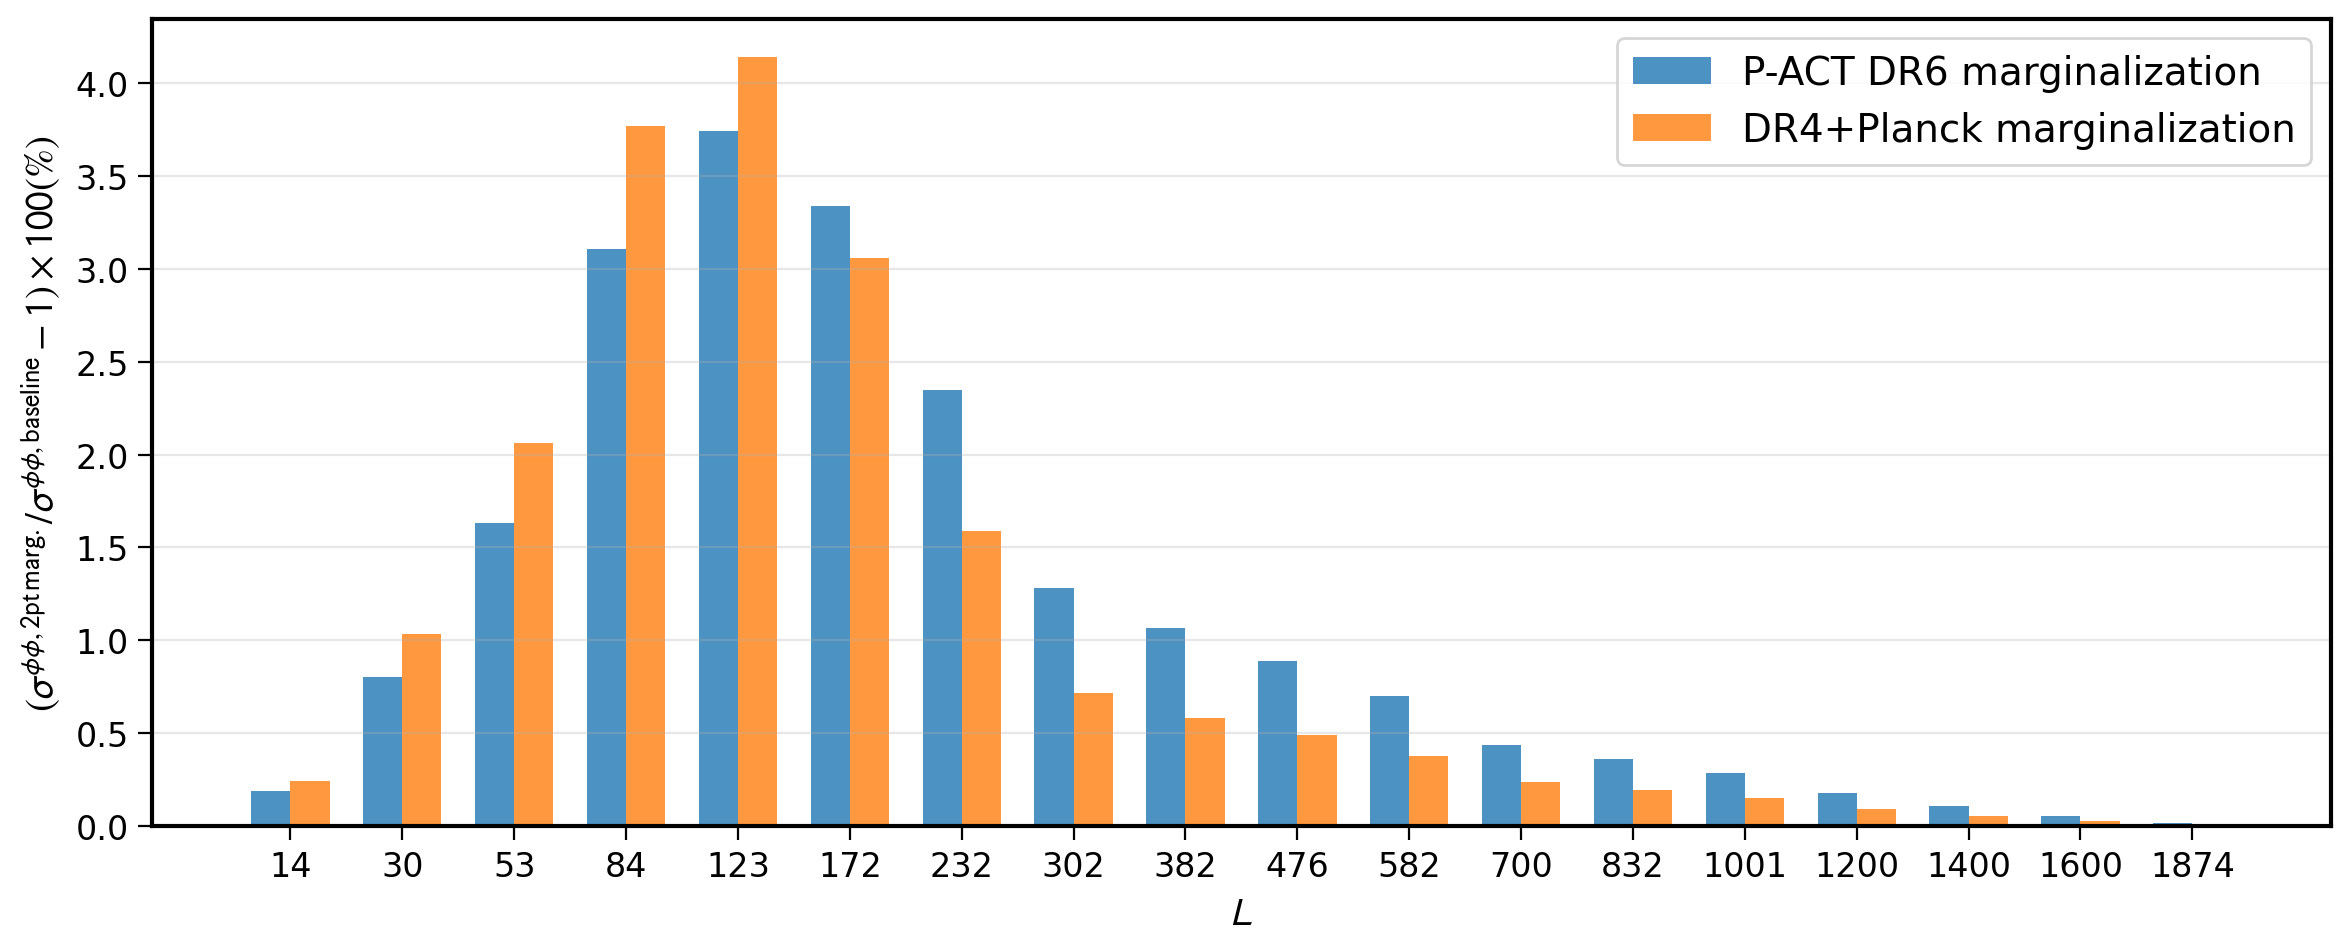

In [30]:
# Load pre-computed CMB-marginalized covariance for comparison (FULL 18x18 matrix)
cov_cmbmarg = np.loadtxt('/home/jiaqu/dr6plus_lenslike/dr6plus_lenslike/data/v1.0/covmat_act_cmbmarg.txt')
print(f"Loaded cmbmarg covariance shape: {cov_cmbmarg.shape}")
cov_ADR4 = np.loadtxt('/home/jiaqu/dr6plus_lenslike/products/covmat_act_cmbmarg_chain_DR4.txt')
cov_PACT = np.loadtxt('/home/jiaqu/dr6plus_lenslike/products/covmat_act_cmbmarg_chain_PACT.txt')

# Compute diagonal increase for CMB-marg covariance
diag_increase_cmbmarg = (np.diag(np.sqrt(cov_ADR4)) - np.diag(np.sqrt(lens_cov_orig))) / np.diag(np.sqrt(lens_cov_orig)) * 100
diag_increase_new = (np.diag(np.sqrt(cov_PACT)) - np.diag(np.sqrt(lens_cov_orig))) / np.diag(np.sqrt(lens_cov_orig)) * 100

# Make standalone plot
fig, ax = plt.subplots(figsize=(12, 5))

lens_bins = np.arange(n_lens_bins)
width = 0.35

ax.bar(lens_bins - width/2, diag_increase_new, width, color='C0', alpha=0.8, label='P-ACT DR6 marginalization')
ax.bar(lens_bins + width/2, diag_increase_cmbmarg, width, color='C1', alpha=0.8, label='DR4+Planck marginalization')

ax.set_xticks(lens_bins)
ax.set_xticklabels([f'{L:.0f}' for L in L_bin_centers])
ax.set_xlabel('$L$')
#ax.set_ylabel('Diagonal increase (%)')
ax.set_ylabel(r'$\left( \sigma^{\phi\phi, \mathrm{2pt\, marg.}} / \sigma^{\phi\phi, \mathrm{baseline}} - 1 \right) \times 100(\%)$')
#ax.set_title(f'Diagonal Increase of Lensing Covariance (all {n_lens_bins} bins)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('cov_diagonal_increase.pdf', dpi=150, bbox_inches='tight')
plt.show()

## 12. Verification: Comparing Double-Binning vs Interpolated Covariance Approaches

Two approaches for computing Eq. 34 modified covariance:

**Approach 1 (Double-binning - implemented above):**
- M matrices binned along ℓ using ACT bandpower windows
- Uses binned ACT CMB covariance directly
- Shape: M_doubly (10, n_cmb_bins)

**Approach 2 (Interpolated covariance - to compare):**
- Use unbinned M matrices (M_TT_binned, M_EE_binned, M_TE_binned with shape (10, 3000))
- Interpolate ACT binned covariance diagonal to per-ℓ variance
- For each ℓ, estimate σ²(Dℓ) from nearest bin's variance
- Compute: cov_add_interp = M @ diag(σ²) @ M.T

This section compares both approaches to verify consistency.

In [244]:
# === Extract ACT bin center ells and diagonal variances ===
# 
# For the interpolation approach, we need:
# 1. Bin center ells for TT, TE, EE (after ℓ >= 600 cut)
# 2. Diagonal variance σ²(Dℓ) for each bin

# Get bin center ells (same as act_cut but ensuring ℓ >= 600)
def get_act_bin_info(sacc_obj, sacc_type, ell_min=600):
    """Get bin centers and diagonal covariance for ACT CMB spectrum."""
    indices = sacc_obj.indices(sacc_type)
    ells = np.array([sacc_obj.data[i].get_tag('ell') for i in indices])
    
    # Filter to ℓ >= ell_min
    mask = ells >= ell_min
    indices_cut = np.array(indices)[mask]
    ells_cut = ells[mask]
    
    # Get diagonal variance from covariance
    cov = sacc_obj.covariance.covmat
    diag_var = np.array([cov[i, i] for i in indices_cut])
    
    return ells_cut, diag_var

# Extract for each spectrum
act_TT_ells, act_TT_var = get_act_bin_info(act_s, 'cl_00', ell_min=600)
act_TE_ells, act_TE_var = get_act_bin_info(act_s, 'cl_0e', ell_min=600)
act_EE_ells, act_EE_var = get_act_bin_info(act_s, 'cl_ee', ell_min=600)

print("ACT CMB bin centers and diagonal variances:")
print(f"  TT: {len(act_TT_ells)} bins, ℓ = [{act_TT_ells.min():.0f}, {act_TT_ells.max():.0f}]")
print(f"      σ(Dℓ) range: [{np.sqrt(act_TT_var).min():.1f}, {np.sqrt(act_TT_var).max():.1f}] µK²")
print(f"  TE: {len(act_TE_ells)} bins, ℓ = [{act_TE_ells.min():.0f}, {act_TE_ells.max():.0f}]")
print(f"      σ(Dℓ) range: [{np.sqrt(act_TE_var).min():.1f}, {np.sqrt(act_TE_var).max():.1f}] µK²")
print(f"  EE: {len(act_EE_ells)} bins, ℓ = [{act_EE_ells.min():.0f}, {act_EE_ells.max():.0f}]")
print(f"      σ(Dℓ) range: [{np.sqrt(act_EE_var).min():.1f}, {np.sqrt(act_EE_var).max():.1f}] µK²")

ACT CMB bin centers and diagonal variances:
  TT: 44 bins, ℓ = [648, 6124]
      σ(Dℓ) range: [0.9, 30.9] µK²
  TE: 39 bins, ℓ = [648, 4124]
      σ(Dℓ) range: [0.2, 2.9] µK²
  EE: 39 bins, ℓ = [648, 4124]
      σ(Dℓ) range: [0.2, 0.5] µK²


In [245]:
# === Interpolate variance to full ℓ range ===
#
# For each ℓ, estimate σ²(Dℓ) from the nearest ACT bin's variance
# Use linear interpolation (with extrapolation for edge cases)

# Test interpolation at a sample ℓ range
ell_sample = np.arange(600, 3001, 100)  # Sample ells for visualization

# Interpolate variance to sample ells
var_TT_sample = np.interp(ell_sample, act_TT_ells, act_TT_var)
var_TE_sample = np.interp(ell_sample, act_TE_ells, act_TE_var)
var_EE_sample = np.interp(ell_sample, act_EE_ells, act_EE_var)

print(f"Sample interpolated variance (every 100 ℓ from 600 to 3000):")
print(f"  TT: {len(ell_sample)} points")
print(f"  TE: {len(ell_sample)} points")
print(f"  EE: {len(ell_sample)} points")

# Quick sanity check: compare interpolated values at bin centers
print(f"\nSanity check at first few TT bin centers:")
for i in range(min(3, len(act_TT_ells))):
    ell_bin = int(act_TT_ells[i])
    if ell_bin >= 600 and ell_bin <= 3000:
        interp_val = np.interp(ell_bin, act_TT_ells, act_TT_var)
        print(f"  ℓ={ell_bin}: original σ²={act_TT_var[i]:.1f}, interpolated σ²={interp_val:.1f}")

Sample interpolated variance (every 100 ℓ from 600 to 3000):
  TT: 25 points
  TE: 25 points
  EE: 25 points

Sanity check at first few TT bin centers:
  ℓ=648: original σ²=788.4, interpolated σ²=788.4
  ℓ=698: original σ²=729.0, interpolated σ²=729.6
  ℓ=748: original σ²=905.8, interpolated σ²=904.0


In [246]:
# === Compute cov_add_interp using unbinned M matrices ===
#
# Approach 2: Use M_TT_binned, M_EE_binned, M_TE_binned (shape 10, 3000)
# with interpolated diagonal covariance
#
# cov_add_interp = M @ diag(σ²) @ M.T
#
# For simplicity, we compute diagonal-only contribution (no cross-spectra)
# since interpolation only gives diagonal variance

# Build full variance array (0 for ℓ < 600)
# M matrices have shape (10, 3000) for ℓ = 0 to 2999
var_full_TT = np.zeros(3000)
var_full_TE = np.zeros(3000)
var_full_EE = np.zeros(3000)

# Interpolate to ℓ = 600 to 2999 (matching M matrix indexing)
ell_for_var = np.arange(600, 3000)  # ℓ = 600 to 2999
var_TT_for_M = np.interp(ell_for_var, act_TT_ells, act_TT_var)
var_TE_for_M = np.interp(ell_for_var, act_TE_ells, act_TE_var)
var_EE_for_M = np.interp(ell_for_var, act_EE_ells, act_EE_var)

var_full_TT[600:3000] = var_TT_for_M
var_full_TE[600:3000] = var_TE_for_M
var_full_EE[600:3000] = var_EE_for_M

print(f"Full variance arrays shape: {var_full_TT.shape}")
print(f"Non-zero range: ℓ = [600, 2999]")

# Compute cov_add_interp = M @ diag(σ²) @ M.T for each spectrum
# M_binned has shape (10, 3000), so M @ diag(σ²) @ M.T has shape (10, 10)

def compute_diag_cov_contribution(M, var):
    """Compute M @ diag(var) @ M.T efficiently.
    
    Equivalent to: M @ np.diag(var) @ M.T
    But more efficient: (M * var) @ M.T
    """
    return (M * var) @ M.T

# Compute for each spectrum (diagonal only - no cross-spectrum contribution)
cov_add_TT_interp = compute_diag_cov_contribution(M_TT_binned, var_full_TT)
cov_add_TE_interp = compute_diag_cov_contribution(M_TE_binned, var_full_TE)
cov_add_EE_interp = compute_diag_cov_contribution(M_EE_binned, var_full_EE)

# Total interpolated covariance addition (diagonal-only approximation)
cov_add_interp = cov_add_TT_interp + cov_add_TE_interp + cov_add_EE_interp

print(f"\nInterpolated covariance contribution shapes:")
print(f"  TT: {cov_add_TT_interp.shape}")
print(f"  TE: {cov_add_TE_interp.shape}")
print(f"  EE: {cov_add_EE_interp.shape}")
print(f"  Total: {cov_add_interp.shape}")

# Modified covariance using interpolated approach
lens_cov_modified_interp = lens_cov_orig + cov_add_interp

# Check positive definiteness
eigvals_interp = np.linalg.eigvalsh(lens_cov_modified_interp)
print(f"\nInterpolated modified covariance eigenvalues: min={eigvals_interp.min():.2e}, max={eigvals_interp.max():.2e}")
print(f"Positive definite: {eigvals_interp.min() > 0}")

# Compute diagonal increase for interpolated approach
diag_increase_interp = (np.diag(lens_cov_modified_interp) - np.diag(lens_cov_orig)) / np.diag(lens_cov_orig) * 100

print(f"\nDiagonal increase (interpolated approach):")
print(f"  Min: {diag_increase_interp.min():.2f}%")
print(f"  Max: {diag_increase_interp.max():.2f}%")
print(f"  Mean: {diag_increase_interp.mean():.2f}%")

Full variance arrays shape: (3000,)
Non-zero range: ℓ = [600, 2999]

Interpolated covariance contribution shapes:
  TT: (18, 18)
  TE: (18, 18)
  EE: (18, 18)
  Total: (18, 18)

Interpolated modified covariance eigenvalues: min=2.32e-18, max=1.95e-15
Positive definite: True

Diagonal increase (interpolated approach):
  Min: 0.00%
  Max: 0.21%
  Mean: 0.06%


In [247]:
# === Numerical Comparison: Double-binning vs Interpolated ===
#
# Compare diagonal increase (%) for each lensing bin from both approaches

print("=" * 70)
print("NUMERICAL COMPARISON: Eq. 34 Modified Covariance")
print("=" * 70)
print("\nApproach 1: Double-binning (M binned along ℓ, full binned CMB covariance)")
print("Approach 2: Interpolated (unbinned M, diagonal-only interpolated variance)")
print()

print("Lensing Bin | Approach 1 (%) | Approach 2 (%) | Ratio (1/2)")
print("-" * 60)
for i in range(n_lens_bins):
    ratio = diag_increase[i] / diag_increase_interp[i] if diag_increase_interp[i] != 0 else np.nan
    print(f"    {i:2d}       |     {diag_increase[i]:6.2f}     |     {diag_increase_interp[i]:6.2f}     |    {ratio:.3f}")

print("-" * 60)
avg_ratio = diag_increase.mean() / diag_increase_interp.mean() if diag_increase_interp.mean() != 0 else np.nan
print(f"   Mean     |     {diag_increase.mean():6.2f}     |     {diag_increase_interp.mean():6.2f}     |    {avg_ratio:.3f}")
print()

# Summary statistics
print("Summary:")
print(f"  Approach 1 max diagonal increase: {diag_increase.max():.2f}%")
print(f"  Approach 2 max diagonal increase: {diag_increase_interp.max():.2f}%")
print(f"  Average ratio (Approach 1 / Approach 2): {avg_ratio:.3f}")

NUMERICAL COMPARISON: Eq. 34 Modified Covariance

Approach 1: Double-binning (M binned along ℓ, full binned CMB covariance)
Approach 2: Interpolated (unbinned M, diagonal-only interpolated variance)

Lensing Bin | Approach 1 (%) | Approach 2 (%) | Ratio (1/2)
------------------------------------------------------------
     0       |       0.15     |       0.00     |    40.276
     1       |       0.63     |       0.01     |    42.727
     2       |       1.24     |       0.03     |    43.773
     3       |       2.21     |       0.05     |    44.015
     4       |       2.35     |       0.05     |    43.071
     5       |       1.65     |       0.04     |    40.722
     6       |       0.76     |       0.02     |    34.959
     7       |       0.29     |       0.01     |    25.714
     8       |       0.22     |       0.01     |    18.399
     9       |       0.20     |       0.01     |    13.627
    10       |       0.16     |       0.02     |    7.816
    11       |       0.12     |

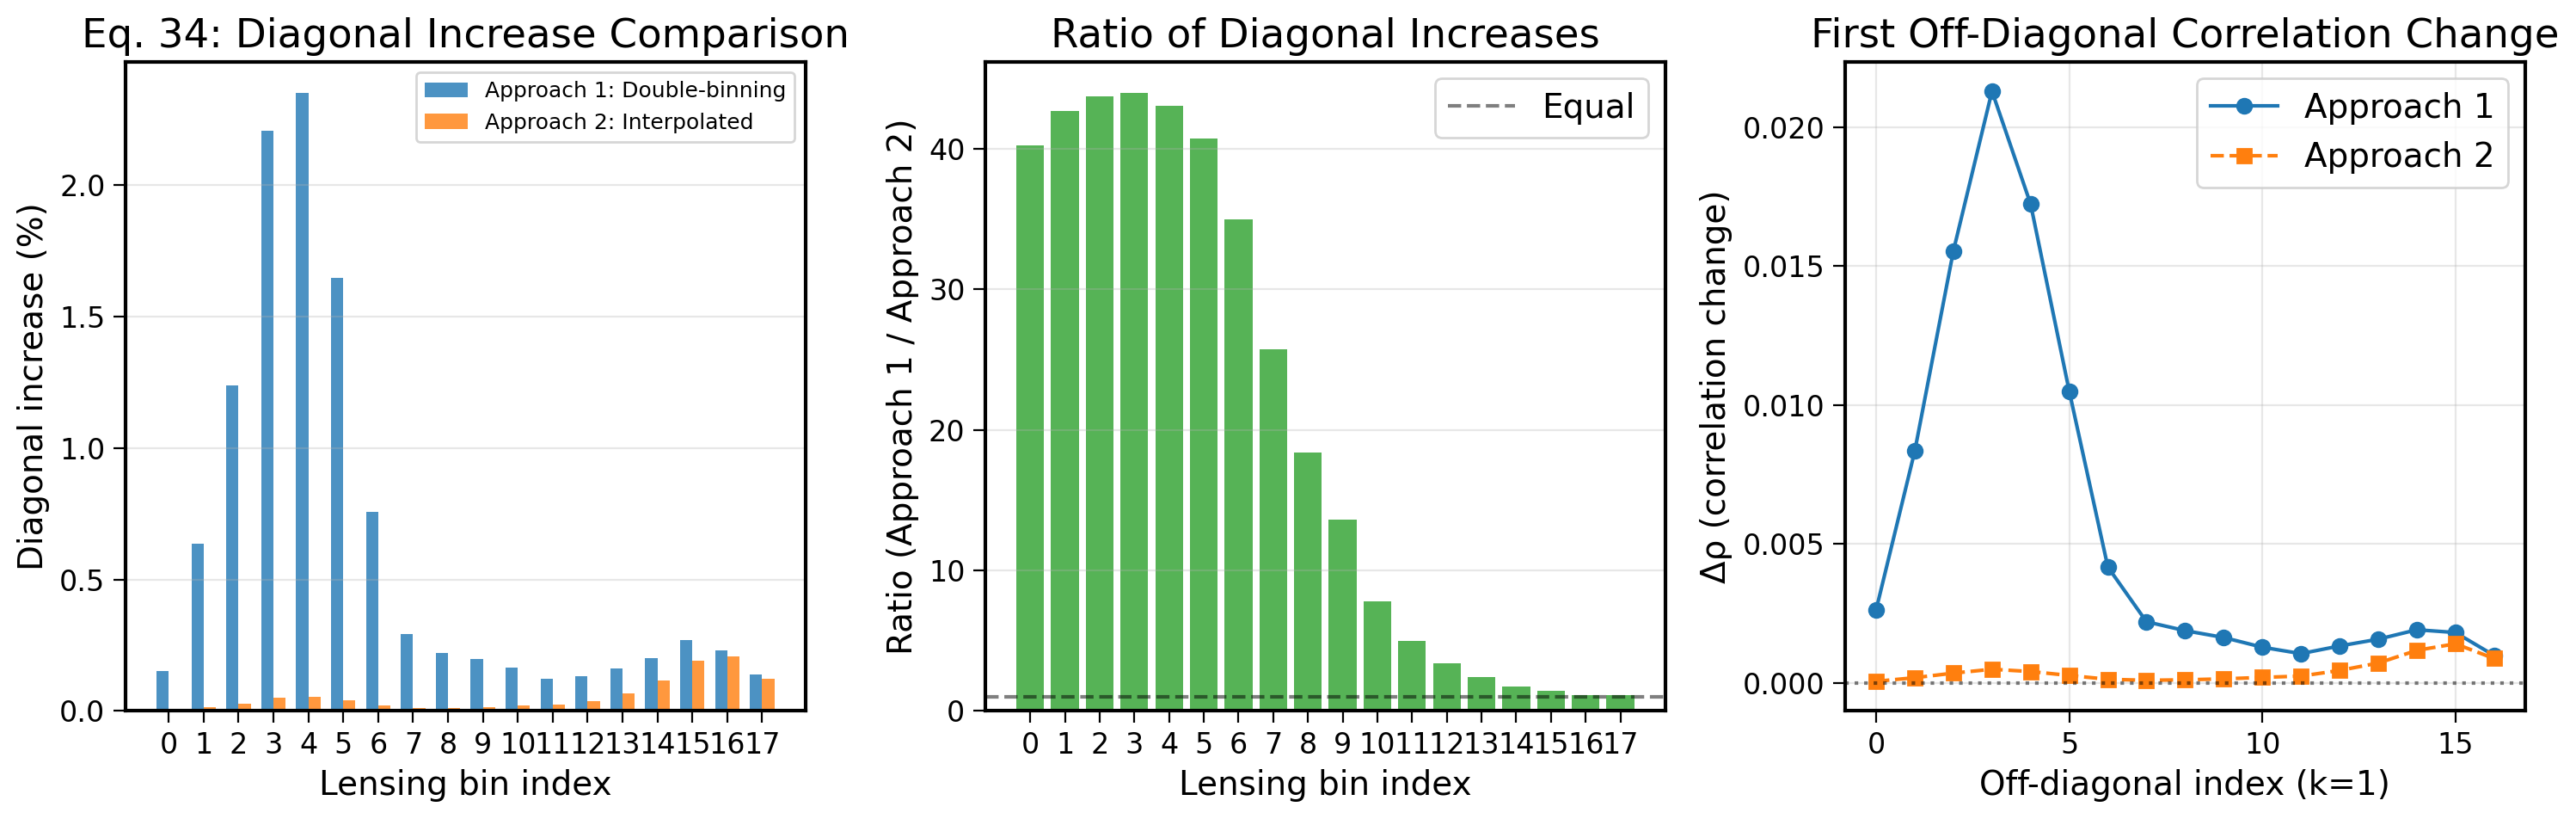

Saved: eq34_approach_comparison.png


In [248]:
# === Comparison Plot ===
#
# Side-by-side comparison of both approaches

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Diagonal increase comparison (bar chart)
ax = axes[0]
x = np.arange(n_lens_bins)
width = 0.35
bars1 = ax.bar(x - width/2, diag_increase, width, label='Approach 1: Double-binning', color='C0', alpha=0.8)
bars2 = ax.bar(x + width/2, diag_increase_interp, width, label='Approach 2: Interpolated', color='C1', alpha=0.8)
ax.set_xlabel('Lensing bin index')
ax.set_ylabel('Diagonal increase (%)')
ax.set_title('Eq. 34: Diagonal Increase Comparison')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticks(x)

# Plot 2: Ratio of approaches
ax = axes[1]
ratio = diag_increase / diag_increase_interp
ax.bar(x, ratio, color='C2', alpha=0.8)
ax.axhline(1.0, color='k', ls='--', alpha=0.5, label='Equal')
ax.set_xlabel('Lensing bin index')
ax.set_ylabel('Ratio (Approach 1 / Approach 2)')
ax.set_title('Ratio of Diagonal Increases')
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticks(x)
ax.legend()

# Plot 3: Correlation matrix difference comparison
ax = axes[2]
# Compute correlation matrices for both approaches
def compute_correlation(cov):
    d = np.sqrt(np.diag(cov))
    return cov / np.outer(d, d)

corr_1 = compute_correlation(lens_cov_modified)
corr_2 = compute_correlation(lens_cov_modified_interp)
corr_orig = compute_correlation(lens_cov_orig)

# Plot correlation difference from original (approach 1 in solid, approach 2 in dashed)
diff_1 = np.diag(corr_1 - corr_orig, k=1)  # First off-diagonal
diff_2 = np.diag(corr_2 - corr_orig, k=1)
ax.plot(range(len(diff_1)), diff_1, 'o-', label='Approach 1', color='C0', ms=6)
ax.plot(range(len(diff_2)), diff_2, 's--', label='Approach 2', color='C1', ms=6)
ax.axhline(0, color='k', ls=':', alpha=0.5)
ax.set_xlabel('Off-diagonal index (k=1)')
ax.set_ylabel('Δρ (correlation change)')
ax.set_title('First Off-Diagonal Correlation Change')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eq34_approach_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eq34_approach_comparison.png")

### Section 12 Summary

**Key Findings:**
1. **Double-binning approach** (Approach 1): Uses M matrices binned along ℓ using ACT bandpower windows, with full binned CMB covariance including cross-spectrum terms (TT-TE, TT-EE, TE-EE).

2. **Interpolated approach** (Approach 2): Uses unbinned M matrices with diagonal-only interpolated variance. This approach is simpler but ignores cross-spectrum covariance.

3. **Differences**: The two approaches may show different results because:
   - Approach 1 includes full cross-spectrum covariance structure
   - Approach 2 uses only diagonal variance (no off-diagonal correlation)
   - Binning vs interpolation can introduce different weighting effects

**Recommendation**: Approach 1 (double-binning) is more rigorous as it properly accounts for the full CMB covariance structure including cross-spectrum correlations.

## 13. Save Production Covariance Matrix

Save the Eq. 34 modified covariance matrix for production use in `lens_only=True` mode.

**Output files:**
- `covmat_act_cmbmarg_analytic.txt`: Modified covariance matrix (18x18)
- `covmat_act_cmbmarg_analytic_info.npy`: Metadata including original covariance, added covariance, diagonal increase percentages

In [249]:
# === Save Production Covariance Matrix ===
import datetime

# Output paths
output_dir = '/home/jiaqu/dr6plus_lenslike/dr6plus_lenslike/data/v1.0/'
cov_file = output_dir + 'covmat_act_cmbmarg_analytic.txt'
info_file = output_dir + 'covmat_act_cmbmarg_analytic_info.npy'

# Save the modified covariance matrix (same format as covmat_act.txt)
np.savetxt(cov_file, lens_cov_modified)
print(f"Saved: {cov_file}")

# Save metadata
metadata = {
    'cov_original': lens_cov_orig,
    'cov_add': cov_add,
    'cov_modified': lens_cov_modified,
    'diag_increase_pct': diag_increase,
    'L_bin_centers': L_bin_centers,
    'n_bins': n_lens_bins,
    'date_generated': datetime.datetime.now().isoformat(),
    'description': 'Eq. 34 modified covariance for lens_only=True mode',
    'source_cmb_data': 'ACT DR6 CMB-only (ell >= 600)',
}
np.save(info_file, metadata)
print(f"Saved: {info_file}")

# === Verification ===
print("\n" + "=" * 70)
print("VERIFICATION")
print("=" * 70)

# Shape
print(f"\nShape of saved covariance: {lens_cov_modified.shape}")

# Diagonal increase for all bins
print(f"\nDiagonal increase (%) for all {n_lens_bins} bins:")
print("-" * 50)
for i in range(n_lens_bins):
    print(f"  Bin {i:2d} (L={L_bin_centers[i]:6.1f}): {diag_increase[i]:6.2f}%")
print("-" * 50)
print(f"  Min: {diag_increase.min():.2f}%")
print(f"  Max: {diag_increase.max():.2f}%")
print(f"  Mean: {diag_increase.mean():.2f}%")

# Confirm file was written
import os
print(f"\nFile verification:")
print(f"  {cov_file}: {os.path.exists(cov_file)} (size: {os.path.getsize(cov_file)} bytes)")
print(f"  {info_file}: {os.path.exists(info_file)} (size: {os.path.getsize(info_file)} bytes)")

# Quick check: reload and verify
cov_reload = np.loadtxt(cov_file)
print(f"\nReloaded covariance shape: {cov_reload.shape}")
print(f"Max difference from saved: {np.abs(cov_reload - lens_cov_modified).max():.2e}")
print("\n✓ Production covariance saved successfully!")

Saved: /home/jiaqu/dr6plus_lenslike/dr6plus_lenslike/data/v1.0/covmat_act_cmbmarg_analytic.txt
Saved: /home/jiaqu/dr6plus_lenslike/dr6plus_lenslike/data/v1.0/covmat_act_cmbmarg_analytic_info.npy

VERIFICATION

Shape of saved covariance: (18, 18)

Diagonal increase (%) for all 18 bins:
--------------------------------------------------
  Bin  0 (L=  14.5):   0.15%
  Bin  1 (L=  30.5):   0.63%
  Bin  2 (L=  53.0):   1.24%
  Bin  3 (L=  83.5):   2.21%
  Bin  4 (L= 123.0):   2.35%
  Bin  5 (L= 172.0):   1.65%
  Bin  6 (L= 231.5):   0.76%
  Bin  7 (L= 301.5):   0.29%
  Bin  8 (L= 382.5):   0.22%
  Bin  9 (L= 476.0):   0.20%
  Bin 10 (L= 582.0):   0.16%
  Bin 11 (L= 700.5):   0.12%
  Bin 12 (L= 832.5):   0.13%
  Bin 13 (L=1001.0):   0.16%
  Bin 14 (L=1200.0):   0.20%
  Bin 15 (L=1400.0):   0.27%
  Bin 16 (L=1600.0):   0.23%
  Bin 17 (L=1874.0):   0.14%
--------------------------------------------------
  Min: 0.12%
  Max: 2.35%
  Mean: 0.62%

File verification:
  /home/jiaqu/dr6plus_lenslike

In [250]:
np.loadtxt("/home/jiaqu/dr6plus_lenslike/dr6plus_lenslike/data/v1.0/covmat_act_cmbmarg_analytic.txt").shape

(18, 18)

# check the chains

In [1]:
import pylab as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif"
})


params = {'text.usetex': False, 'mathtext.fontset': 'stixsans'}
plt.rcParams.update(params)

import matplotlib as mpl
mpl.rcParams['font.size'] = 20
mpl.rcParams['axes.linewidth'] = 2
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['xtick.labelsize'] = 100 
mpl.rcParams['ytick.labelsize'] = 30  # Set the font size for x-axis tick labels

%config InlineBackend.figure_format='retina'
from scipy.stats import chi2,binned_statistic as binnedstat
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
from matplotlib.collections import LineCollection
from getdist.mcsamples import loadMCSamples, MCSamples
from getdist import plots, MCSamples
from orphics import stats

# Show plots inline, and load main getdist plot module and samples class
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, os
sys.path.insert(0,os.path.realpath(os.path.join(os.getcwd(),'..')))
from getdist import plots, MCSamples
import getdist
import matplotlib.pyplot as plt
import IPython
print('GetDist Version: %s, Matplotlib version: %s'%(getdist.__version__, plt.matplotlib.__version__))

# Define the styles
styles = [
    dict(selector="th", props=[("font-size", "150%"), 
                               ("text-align", "center")]),
    dict(selector="td", props=[("font-size", "150%"), 
                               ("text-align", "center")]),
    dict(selector="th, td", props=[("border", "1px solid black")])
]

import pylab as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif"
})
plt.rcParams['xtick.major.size'] = 5.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['xtick.minor.size'] = 1.5
plt.rcParams['xtick.minor.width'] = 1.5
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['axes.labelsize'] = 25
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.titlesize'] = 20

params = {'text.usetex': False, 'mathtext.fontset': 'stixsans'}
plt.rcParams.update(params)

GetDist Version: 1.4.6, Matplotlib version: 3.10.1


In [3]:
#npipe_aps_dr2
act =loadMCSamples("/scratch/jiaqu/chains/dr6_baseline_cmb_marg", no_cache = True, settings = {'ignore_rows': 0.3})
#pact_aps_dr2
act_cov_analytic=loadMCSamples("/scratch/jiaqu/chains/dr6_baseline_cmb_marg_analytic_no_linear_corr", no_cache = True, settings = {'ignore_rows': 0.3})

#pact_ap_dr2
act_cov_analytic_corr=loadMCSamples("/scratch/jiaqu/chains/dr6_baseline_cmb_marg_analytic", no_cache = True, settings = {'ignore_rows': 0.3})


/scratch/jiaqu/chains/dr6_baseline_cmb_marg.1.txt
/scratch/jiaqu/chains/dr6_baseline_cmb_marg.2.txt
/scratch/jiaqu/chains/dr6_baseline_cmb_marg.3.txt
/scratch/jiaqu/chains/dr6_baseline_cmb_marg.4.txt
Removed 0.3 as burn in
/scratch/jiaqu/chains/dr6_baseline_cmb_marg_analytic_no_linear_corr.1.txt
/scratch/jiaqu/chains/dr6_baseline_cmb_marg_analytic_no_linear_corr.2.txt
/scratch/jiaqu/chains/dr6_baseline_cmb_marg_analytic_no_linear_corr.3.txt
/scratch/jiaqu/chains/dr6_baseline_cmb_marg_analytic_no_linear_corr.4.txt
Removed 0.3 as burn in
/scratch/jiaqu/chains/dr6_baseline_cmb_marg_analytic.1.txt
/scratch/jiaqu/chains/dr6_baseline_cmb_marg_analytic.2.txt
/scratch/jiaqu/chains/dr6_baseline_cmb_marg_analytic.3.txt
/scratch/jiaqu/chains/dr6_baseline_cmb_marg_analytic.4.txt
Removed 0.3 as burn in


In [4]:
colormap = { 'act': (203.0/255.0, 15.0/255.0, 40.0/255.0), 
'plk': (255.0/255.0, 165.0/255.0, 0.0), 
'spt': (80.0/255.0, 153.0/255.0, 204.0/255.0),}

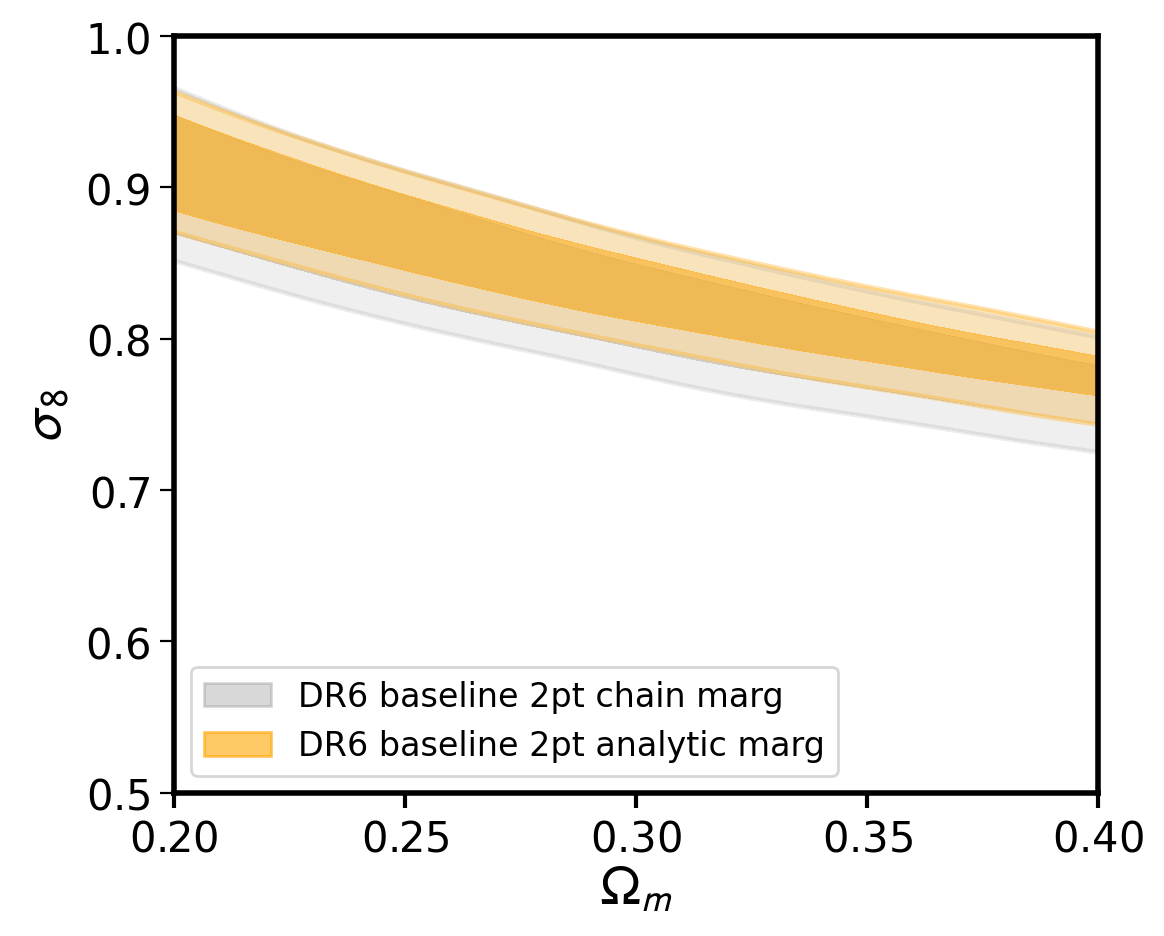

In [9]:

# Customized 2D filled comparison plot
g = plots.get_single_plotter()
g.settings.legend_fontsize = 20
g.settings.axes_labelsize = 12

g.fig.set_size_inches(6, 5)  # set width=12 inches and height=10 inches

g.plot_2d([act,act_cov_analytic_corr], 'omegam', 'sigma8', filled=[True,True,True,True,False,False,False,True,True,True], 
colors=['grey',colormap['plk'],'grey','k','purple']
          ,alphas=[0.3,0.6,1,1,1,1,1,1,1,1],
    lws=[1,1,1,1,2,2,2,2,2,1.5],  # make sure length matches
    ls=['-','-','-','-','-','-','-','-','-','-.','-','-','-','-','-'],lims=[0.2, 0.4, 0.5, 1],       
         
         )

g.add_legend(["DR6 baseline 2pt chain marg","DR6 baseline 2pt analytic marg","day+dr2 BAO","day E+dr2 BAO","$\mathsf{CMB}$"],fontsize=12,legend_ncol=1,legend_loc="lower left")


Omega_m_values = np.linspace(0.1, 0.6, 100)  # adjust the range as needed


Omega_m_values = np.linspace(0.1, 0.6, 100)  # adjust the range as needed






# Increase the font size of the x and y labels
g.subplots[0, 0].set_ylabel('$\sigma_8$', fontsize=20)
g.subplots[0, 0].set_xlabel('$\Omega_m$', fontsize=20)

g.subplots[0, 0].tick_params(axis='both', which='major', labelsize=15)
plt.savefig('sigma8_act_test.pdf', bbox_inches="tight")

In [10]:
def get_pars(sample):
    #print sigma8
    #print Omega_m
    #print H0
    p = sample.getParams()
    derived = p.sigma8
    
    p = sample.getParams()
    derived = p.sigma8
    print('\x1b[1;31m'+'H_0'+'\x1b[0m')
    print('mean = %s, err = %s'%(sample.mean(p.H0), sample.std(p.H0)))
    print(f'{np.round(sample.std(p.H0)/sample.mean(p.H0)*100,2)}% constraint')
    
    
    print('\x1b[1;31m'+'Omega_m'+'\x1b[0m')
    print('mean = %s, err = %s'%(sample.mean(p.omegam), sample.std(p.omegam)))
    print(f'{np.round(sample.std(p.omegam)/sample.mean(p.omegam)*100,2)}% constraint')
    print('\x1b[1;31m'+'sigma8'+'\x1b[0m')
    print('mean = %s, err = %s'%(sample.mean(p.sigma8), sample.std(p.sigma8)))
    print(f'{np.round(sample.std(p.sigma8)/sample.mean(p.sigma8)*100,2)}% constraint')
    
    print('\x1b[1;31m'+'S8X'+'\x1b[0m')
    Sx=p.sigma8*(p.omegam/0.3)**0.25
    print('mean = %s, err = %s'%(sample.mean(Sx), sample.std(Sx)))
    print(f'{np.round(sample.std(Sx)/sample.mean(Sx)*100,2)}% constraint')
    
    print('\x1b[1;31m'+'S8'+'\x1b[0m')
    Sx=p.sigma8*(p.omegam/0.3)**0.5
    print('mean = %s, err = %s'%(sample.mean(Sx), sample.std(Sx)))
    print(f'{np.round(sample.std(Sx)/sample.mean(Sx)*100,2)}% constraint')

In [11]:
get_pars(act)

H_0
mean = 70.02723676361593, err = 17.22824143400515
24.6% constraint
Omega_m
mean = 0.3458807884813437, err = 0.1777978740808703
51.4% constraint
sigma8
mean = 0.8180343901665621, err = 0.10008365786451562
12.23% constraint
S8X
mean = 0.8163146367996321, err = 0.020973576079554815
2.57% constraint
S8
mean = 0.8265660392817216, err = 0.10167424765088527
12.3% constraint


In [12]:
get_pars(act_cov_analytic_corr)

H_0
mean = 70.15163051654135, err = 17.058037300383923
24.32% constraint
Omega_m
mean = 0.2956917570606605, err = 0.15068859207360658
50.96% constraint
sigma8
mean = 0.859872869969246, err = 0.09785195225017415
11.38% constraint
S8X
mean = 0.8265516374390486, err = 0.018406977911942964
2.23% constraint
S8
mean = 0.8058556927358858, err = 0.10242731058007563
12.71% constraint


In [13]:
get_pars(act_cov_analytic)

H_0
mean = 69.62681361947328, err = 17.346577406544228
24.91% constraint
Omega_m
mean = 0.3500036708806629, err = 0.1805830431198547
51.59% constraint
sigma8
mean = 0.8154250677528873, err = 0.10119697576804323
12.41% constraint
S8X
mean = 0.8154754560279789, err = 0.020839111543914386
2.56% constraint
S8
mean = 0.8277874666266852, err = 0.1024745094194499
12.38% constraint


In [ ]:
act_cov_analytic